In [3]:
%load_ext autoreload
%autoreload 2

In [4]:

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingEnergy as AFtask


In [5]:
modelname = 'vary_reward_energyV6'

epoch_size = 33333
n_epoch = 33
n_seed = 1
seed = 0
np.random.seed(seed)

# vary conditions
vmin, vmax = 100,2000
food_reward_list = np.linspace(vmin, vmax, 5)
plist = [np.array([.5, .7])]
node_list = [25]
# fixed params
attcost = -1.6
facost = -50
env_param = [0, None, attcost, .25, facost, 0, 0]

# for plotting
no_episodes = 2222  # for eval plot during training
plot_no_episodes = 555  # for raster plot
minlen, maxlen = 0, np.inf
nbin = 15
bins = np.linspace(0, 1, nbin)

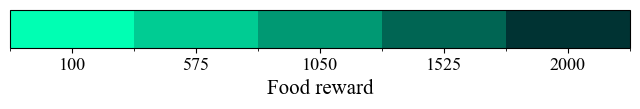

In [6]:
# color bars
num_discrete_var = len(food_reward_list)
discrete_colors = rewardcmap(np.linspace(0, 1, num_discrete_var))
discrete_cmap = ListedColormap(discrete_colors)
boundaries = np.arange(num_discrete_var + 1)
norm = BoundaryNorm(boundaries, num_discrete_var)
fig, ax = plt.subplots(figsize=(8, 1))
fig.subplots_adjust(bottom=0.5)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=discrete_cmap),
    cax=ax,
    orientation='horizontal',
    ticks=np.arange(num_discrete_var) + 0.5
)
cbar.set_label('Food reward')
cbar.set_ticks(np.arange(num_discrete_var) + 0.5)
cbar.set_ticklabels([f'{int(a)}' for a in food_reward_list])
plt.show()


In [7]:
# helper and plot function
def process_one_subdf_df(subdf,no_signal_nodes=25, no_penalty_nodes=1):
    '''process the subdf data into result lists. the input is a df'''
    hit_count = 0
    miss_count = 0
    false_alarm_count = 0
    noise_time_before_lick = 0
    signal_time_before_lick = 0
    total_noise_time = 0
    total_signal_time = 0
    total_reward = 0

    attention_time_points_across_subdfs = []
    subdf_length_across_subdfs = []
    hit_reaction_time_across_subdfs = []
    fa_reaction_time_across_subdfs = []

    # process single ep data
    if subdf['actions'][-1][0] == 1:
        if subdf['states'][-1][0] >  no_signal_nodes +  no_penalty_nodes:
            hit_count += 1
            signal_time_before_lick_curr_subdf = count_no_elements(
                subdf['states'], 1,  no_signal_nodes)
            hit_reaction_time_across_subdfs.append(
                signal_time_before_lick_curr_subdf)
            signal_time_before_lick += signal_time_before_lick_curr_subdf
        else:
            false_alarm_count += 1
            noise_time_before_lick_curr_subdf = count_no_elements(
                subdf['states'], 0, 0)
            fa_reaction_time_across_subdfs.append(
                noise_time_before_lick_curr_subdf)
            noise_time_before_lick += noise_time_before_lick_curr_subdf
    else:
        miss_count += 1
    total_signal_time += count_no_elements(
        subdf['states'], 1,  no_signal_nodes)
    total_noise_time += count_no_elements(subdf['states'], 0, 0)
    total_reward += sum(subdf['rewards'])
    # attention_time_points_across_subdfs.append(np.where(subdf['actions'] % env.no_attention_modes > 0)[0])
    attention_time_points_across_subdfs.append(
        np.where(np.array([elt[1] for elt in subdf['actions']]) == 1)[0])
    subdf_length_across_subdfs.append(len(subdf['states']))
    # end process single ep data
    food_reward_idx = subdf['trial_food_reward_idx']
    return (food_reward_idx,
            hit_count,
            miss_count,
            false_alarm_count,
            noise_time_before_lick,
            signal_time_before_lick,
            total_noise_time,
            total_signal_time,
            total_reward,
            attention_time_points_across_subdfs,
            subdf_length_across_subdfs,
            hit_reaction_time_across_subdfs,
            fa_reaction_time_across_subdfs
            )

def hit_reaction_plot(df, savemodelname='test'):
    ''' '''
    # process data
    hit_count_list = [[0] for _ in range(len(food_reward_list))]
    miss_count_list = [[0] for _ in range(len(food_reward_list))]
    false_alarm_list = [[0] for _ in range(len(food_reward_list))]

    noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
    signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
    total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
    total_signal_time_list = [[0] for _ in range(len(food_reward_list))]
    # dist naming space: list of list of num. big list of each reward cond. small list of each trial's summary stats, which is a single number.
    total_reward_dist= [[] for _ in range(len(food_reward_list))]
    rt_hit_dist=[[] for _ in range(len(food_reward_list))]
    rt_fa_dist=[[] for _ in range(len(food_reward_list))]
    total_att_time_dist = [[] for _ in range(len(food_reward_list))]

    for i in range(len(df)):
        (food_reward_idx,
        hit_count,
        miss_count,
        false_alarm_count,

        noise_time_before_lick,
        signal_time_before_lick,
        total_noise_time,
        total_signal_time,

        total_reward,

        attention_time_points_across_episodes,
        episode_length_across_episodes,
        hit_reaction_time_across_episodes,
        fa_reaction_time_across_episodes
        ) = process_one_subdf_df(df.iloc[i])

        hit_count_list[food_reward_idx][0] += (hit_count)
        miss_count_list[food_reward_idx][0] += (miss_count)
        false_alarm_list[food_reward_idx][0] += (false_alarm_count)

        noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
        signal_time_before_lick_list[food_reward_idx][0] += (
            signal_time_before_lick)
        total_noise_time_list[food_reward_idx][0] += (total_noise_time)
        total_signal_time_list[food_reward_idx][0] += (total_signal_time)

        total_reward_dist[food_reward_idx].append(total_reward)
        rt_hit_dist[food_reward_idx].append(signal_time_before_lick)
        rt_fa_dist[food_reward_idx].append(noise_time_before_lick)
        total_att_time_dist[food_reward_idx].append(len(attention_time_points_across_episodes[0]))


    # 3 curve plot (figure 4a)
    hit_count_list, miss_count_list, false_alarm_list = np.array(
        hit_count_list), np.array(miss_count_list), np.array(false_alarm_list)
    hit_prob = [hit_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                    false_alarm_list[i]) for i in range(len(hit_count_list))]
    miss_prob = [miss_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                        false_alarm_list[i]) for i in range(len(hit_count_list))]
    fa_prob = [false_alarm_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                    false_alarm_list[i]) for i in range(len(hit_count_list))]

    xs=np.arange(len(food_reward_list))
    fig, ax=plt.subplots(1,1, figsize=(5,4))

    ax.plot(xs, hit_prob, '-*g', label='hit')
    ax.plot(xs, miss_prob, '-*b', label='miss')
    ax.plot(xs, fa_prob, '-*r', label='fa')
    quickleg(ax, bbox_to_anchor=(-0.5,0))
    ax.set_xlabel('food reward')
    ax.set_ylabel('probability')
    # ax.set_xticks(xs, [f'{a:.0f}' for a in food_reward_list]) # actual values
    ax.set_xticks([xs[i] for i in [0,-1]], ['low', 'high']) # low high
    ax.set_xticks(xs)
    ax.set_yticks([0,0.5,1], ['0', '.5','1'])
    ax.set_xticks(xs)
    centerax(ax)
    ax.set_title('hit, miss, false alarm')
    quicksave('a', savemodelname)
    plt.show()

    # reaction time (figure 4b)
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    data = []
    for food_reward_idx, v in enumerate(rt_hit_dist):
        v = np.array(v)
        v = v[v > 1]  # ignore the 0 reaction time in the plots
        if len(v) == 0:
            continue
        data.append((food_reward_idx, v))


    for i, (food_reward_idx, curve) in enumerate(data):
        if len(data)>1:
            # print(curve, data)
            sns.kdeplot(curve, label=f'reward:{food_reward_list[food_reward_idx]:.0f}', clip=(1, np.max(curve)), bw_adjust=1,color=rewardcmap(np.linspace(0, 1, len(data)))[i])

    ax.set_ylabel('probability')
    ax.set_xlabel('reaction time')
    centerax(ax)
    ax.set_xticks([0, 10, 20],[0, 10, 20])
    ax.set_yticks([])
    ax.set_yticklabels([])
    # quickleg(ax, bbox_to_anchor=(-0.5, 0))
    ax.set_title('vary reward \n reaction time distribution')
    quicksave('b', savemodelname)
    plt.show()


    # # total attention time distribution, figure 4C
    # fig= plt.figure()
    # for food_reward_idx in np.arange(len(food_reward_list)):
        
    #     subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    #     sns.kdeplot([len(a) for a in subdf.at_times],  label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=2, common_norm=False, color=rewardcmap(
    #         np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])

    #     plt.xlim(0, 15)
    #     plt.xticks([0, 15], [0,15])
    #     plt.xlabel('# high attentions')
    #     plt.ylabel('prob')
    #     plt.title(f'total attention times, varying food reward')
    #     centerax(plt.gca())
    #     plt.yticks([])
    # plt.show()



    # autocorelation for peroid. fig4g
    fig, ax1 = plt.subplots(1,1, figsize=(5,4))
    for food_reward_idx in np.arange(len(food_reward_list)):
        subdf=df[df.trial_food_reward_idx==food_reward_idx]
        att_seq_list = []
    
        for episode_actions in subdf.actions:
            att_seq_list.append([float(a[1]) for a in episode_actions])
        
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        # Choosing what range of trial lengths to use. Could modify to be more consistent.
        sequences = sorted_list_of_lists[-plot_no_episodes:]
        # autocorr
        try:
            autocorr, total_counts = empirical_autocorrelation_new(
                sequences, min_no_samples=1111)
            xs = np.arange(0, len(autocorr), 1)
            xs = xs-len(xs)//2
            ax1.plot(xs, autocorr,
                        label=f'node:{1}', color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
        except:
            continue

        # ax1.set_xlabel(r'$\tau$ [s]')
        # # ax1.set_title('auto correlation')
        ax1.set_xlim(-50, 50)
        # ax1.set_ylim(None, 1)
        ax1.set_xticks([-50, 0, 50])
        # ax1.set_yscale('log')
        ax1.set_yticks([1])
        ax1.spines['left'].set_position('zero')
        ax1.spines['bottom'].set_position('zero')
        ax1.tick_params(axis='x', pad=50) 

    
    fig.suptitle(f'vary reward, peroidic')
    plt.tight_layout()
    quicksave('g', savemodelname)
    plt.show()


# training

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch0, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep0 saved
total reward per trial: -1.0


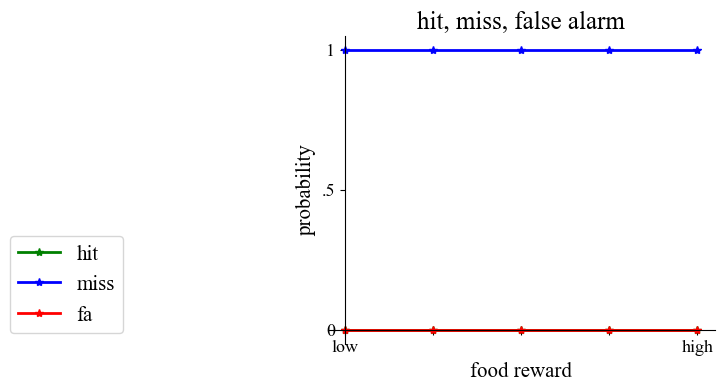

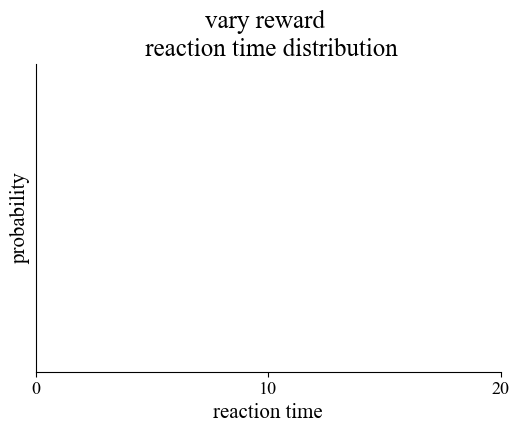

/Users/yc/repo/auditory-foraging-IRC/ult.py:1195: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


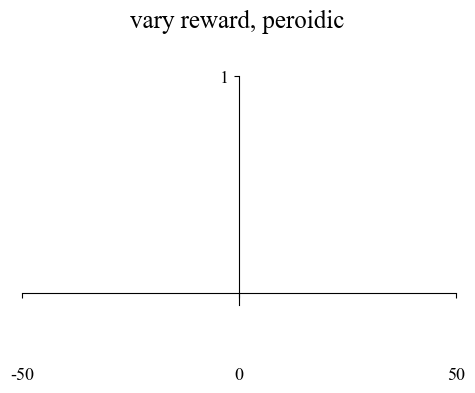

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch1, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep1 saved
total reward per trial: -1.0


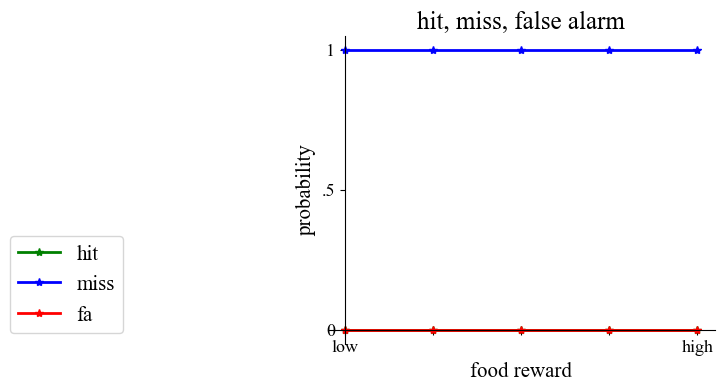

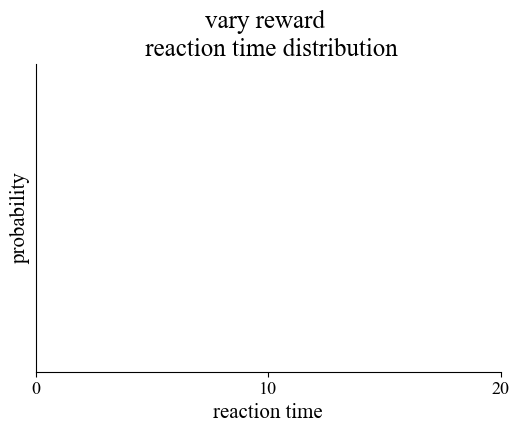

/Users/yc/repo/auditory-foraging-IRC/ult.py:1195: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


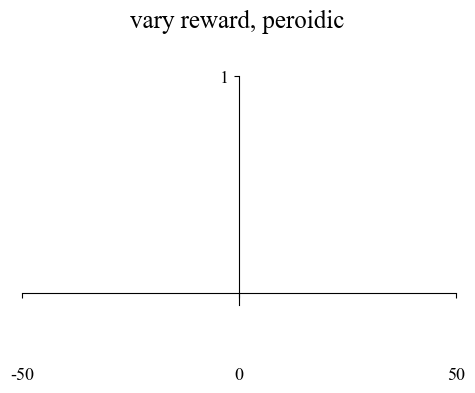

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch2, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep2 saved
total reward per trial: 0.0


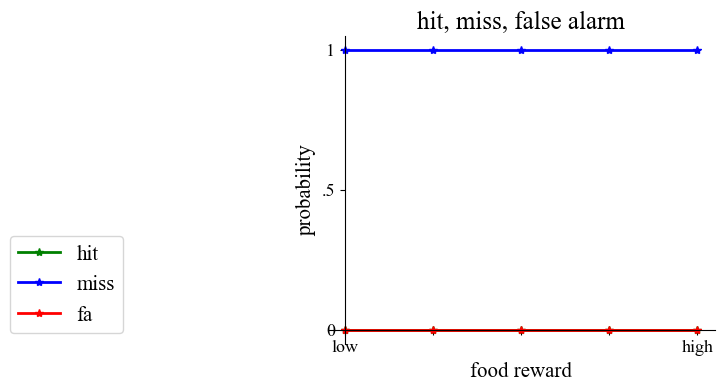

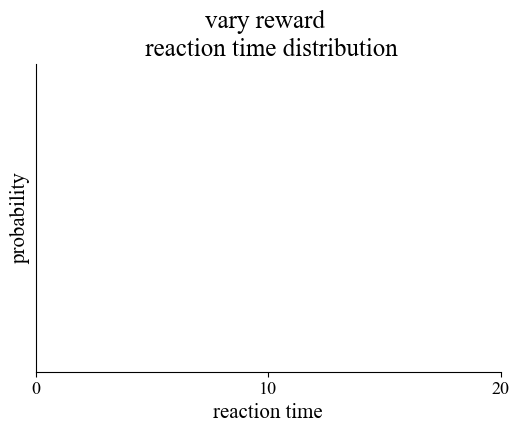

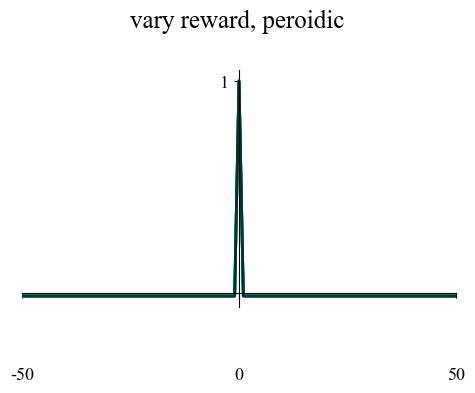

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch3, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep3 saved
total reward per trial: 0.0


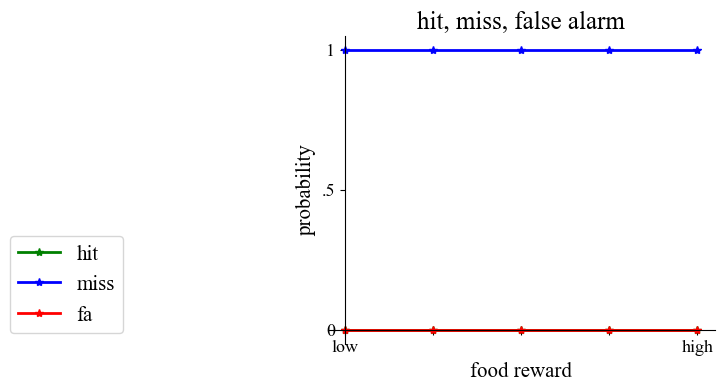

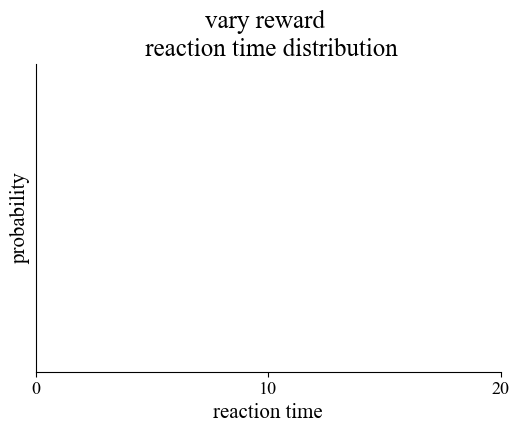

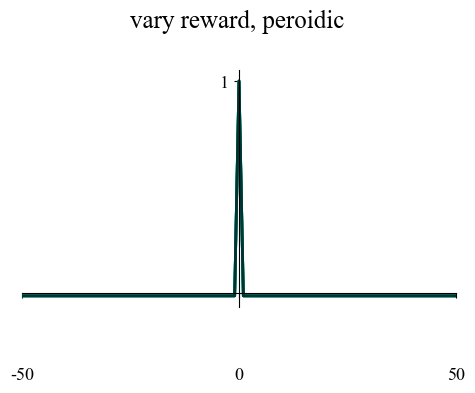

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch4, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep4 saved
total reward per trial: 0.0


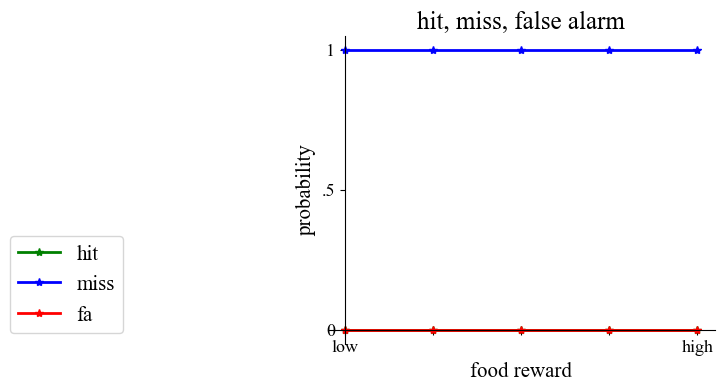

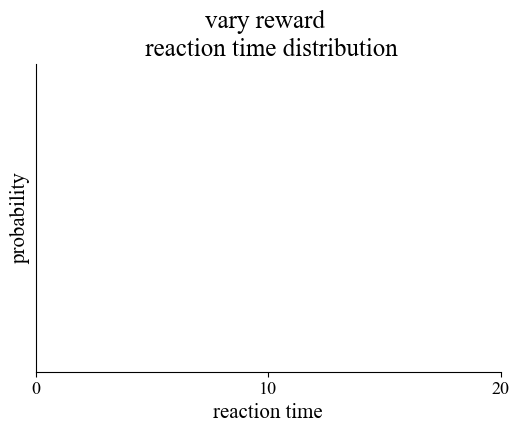

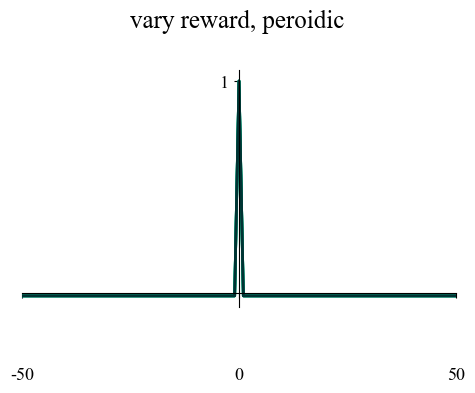

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch5, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep5 saved
total reward per trial: 546.7476561336448


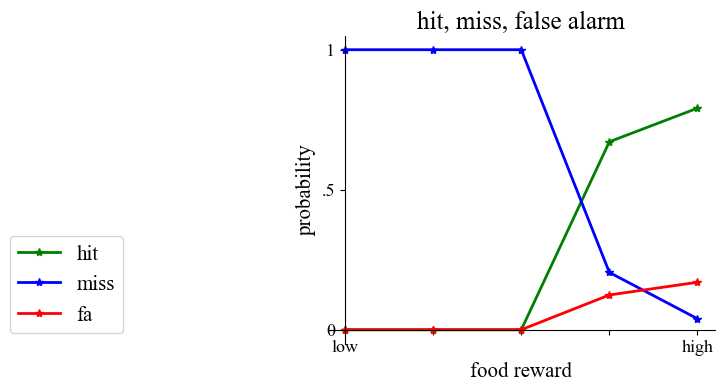

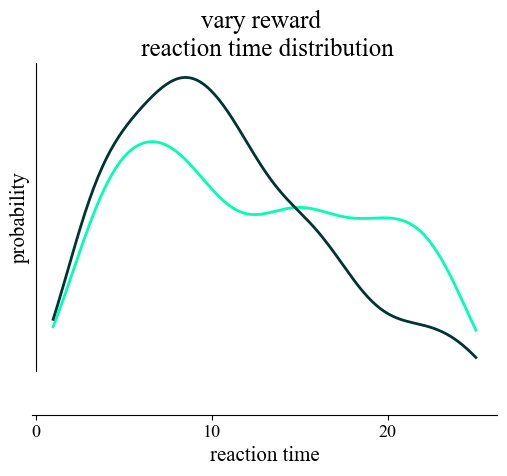

/Users/yc/repo/auditory-foraging-IRC/ult.py:1195: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


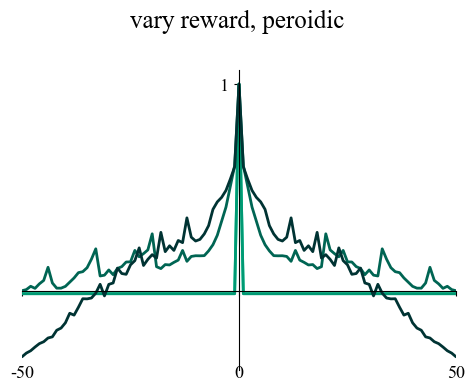

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch6, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep6 saved
total reward per trial: 0.0


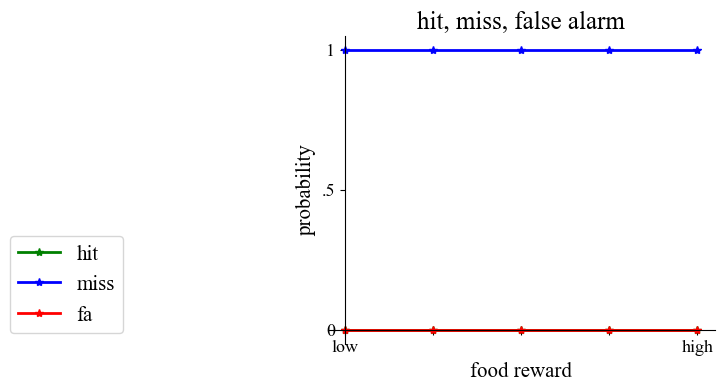

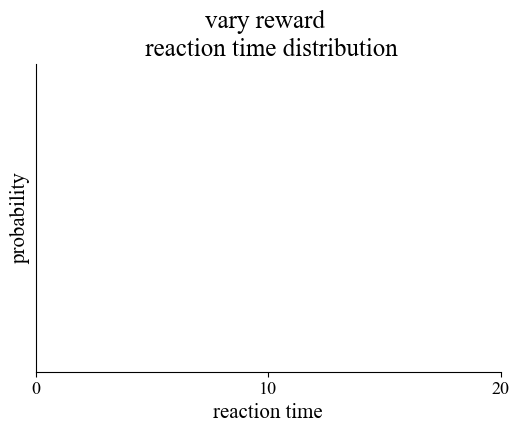

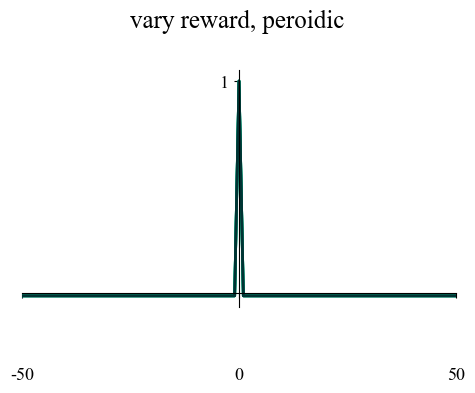

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch7, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep7 saved
total reward per trial: -0.21692169216921692


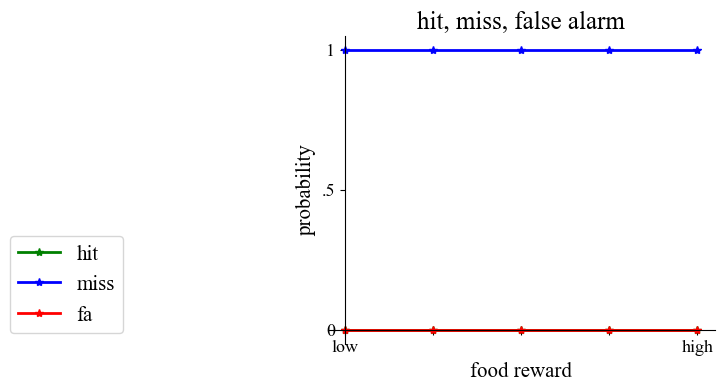

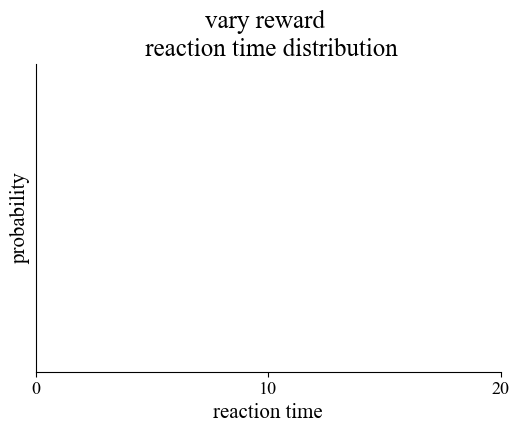

/Users/yc/repo/auditory-foraging-IRC/ult.py:1195: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


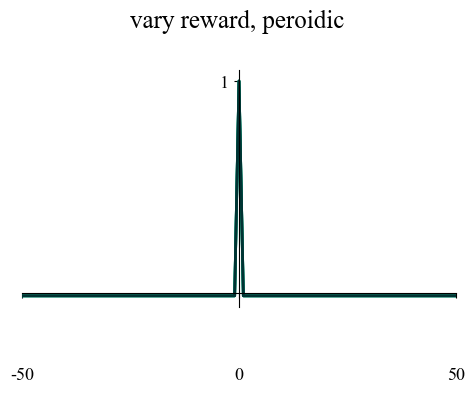

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch8, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep8 saved
total reward per trial: 192.40927404771173


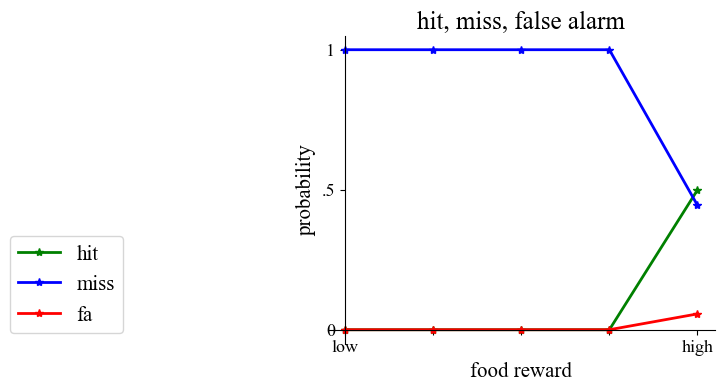

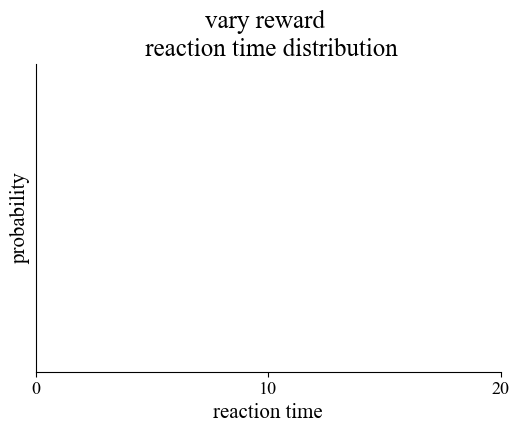

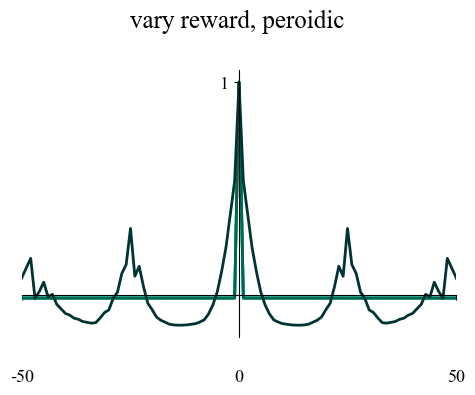

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch9, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep9 saved
total reward per trial: 0.0


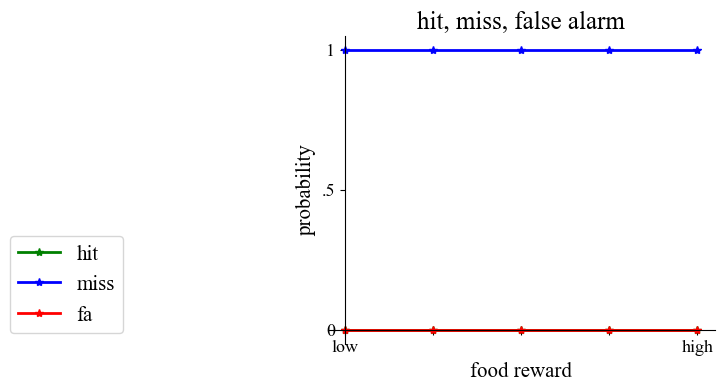

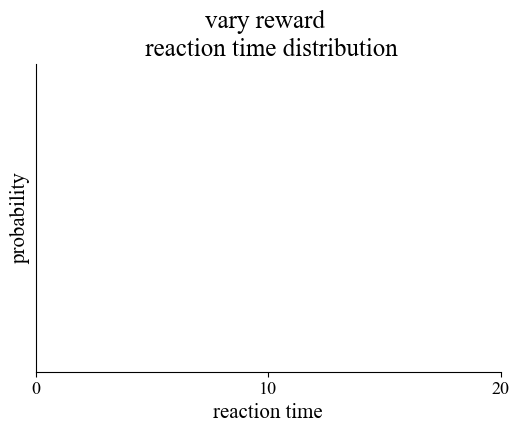

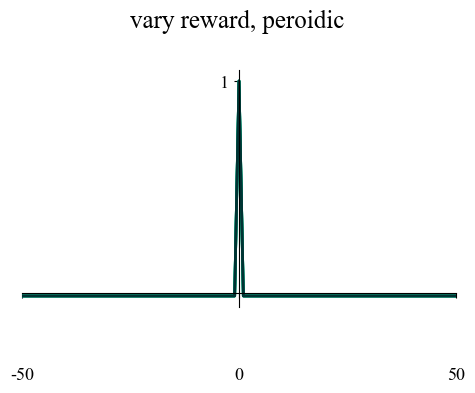

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch10, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep10 saved
total reward per trial: 0.0


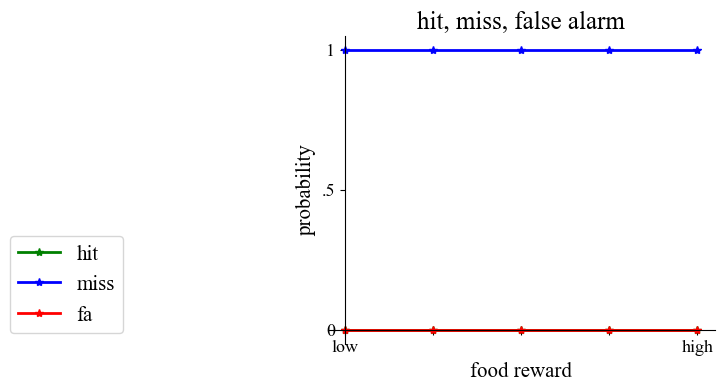

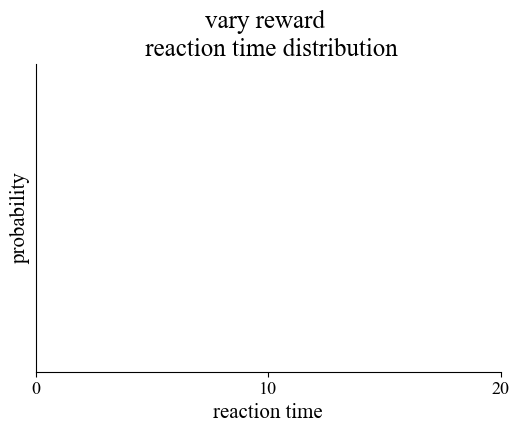

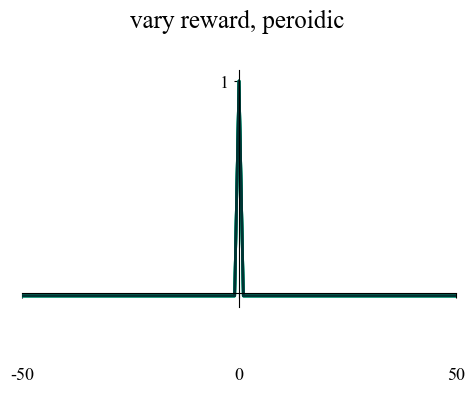

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch11, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep11 saved
total reward per trial: 0.0


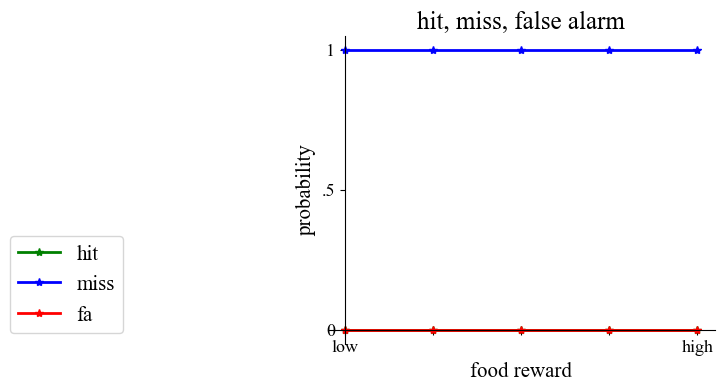

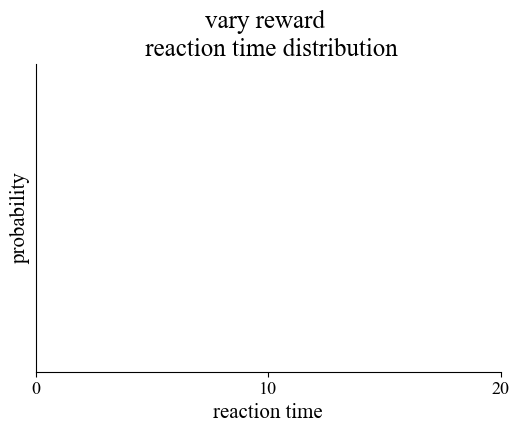

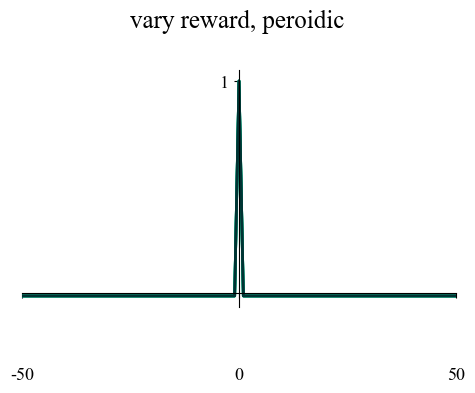

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch12, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep12 saved
total reward per trial: 163.5865394940892


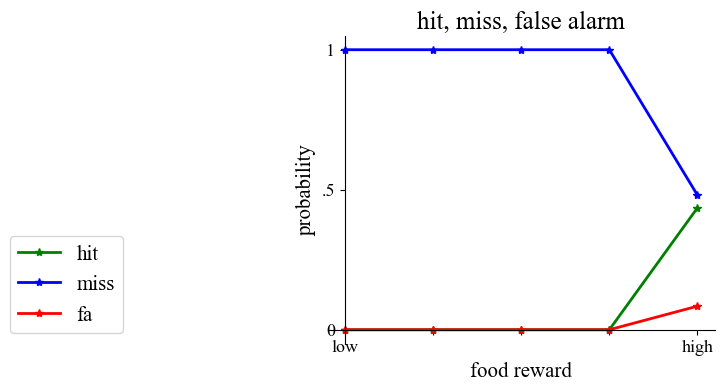

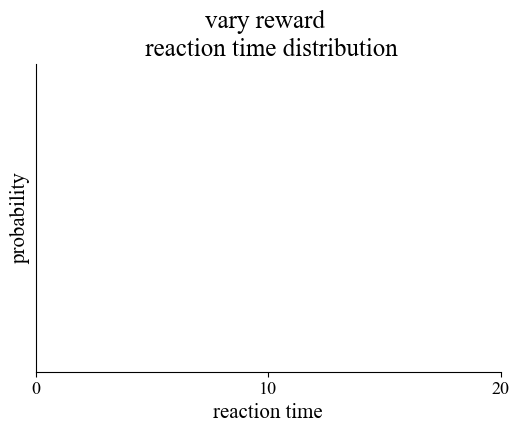

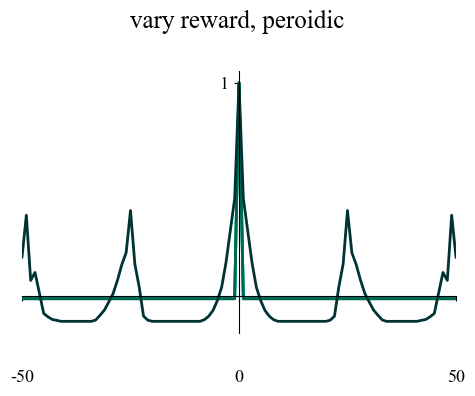

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch13, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep13 saved
total reward per trial: 207.874816725659


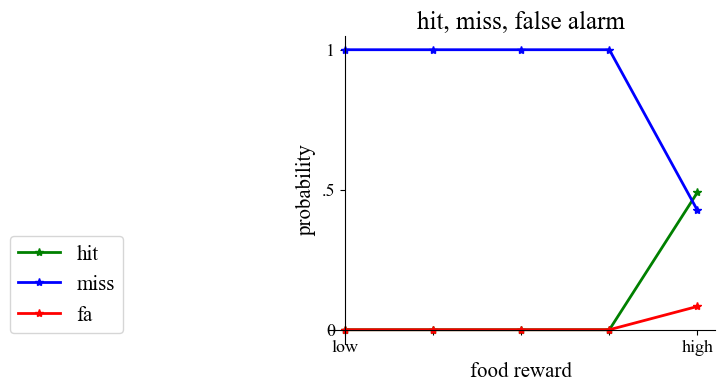

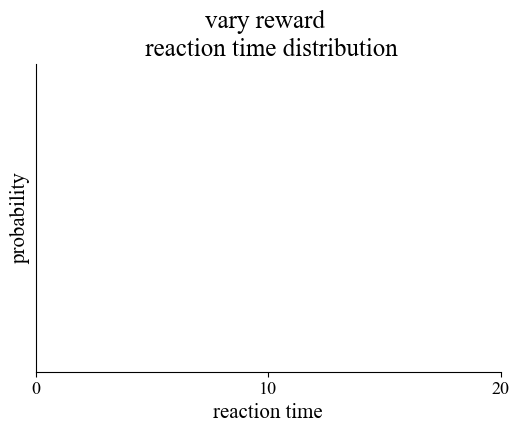

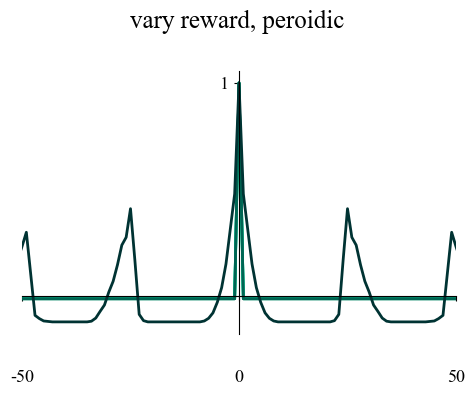

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch14, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep14 saved
total reward per trial: 211.54935020198354


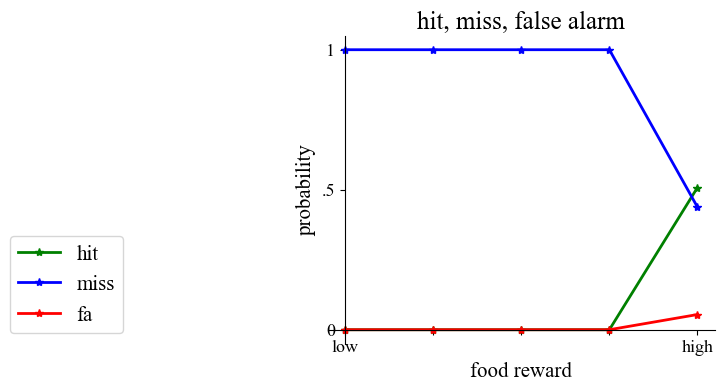

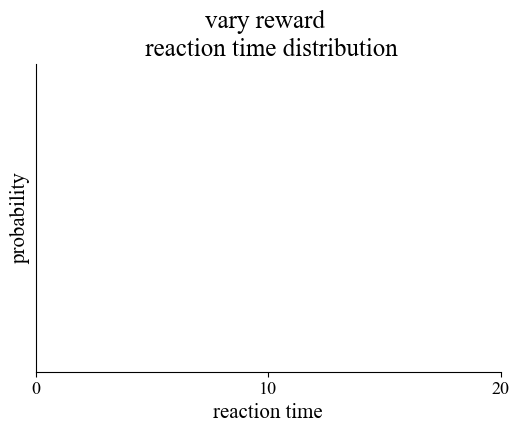

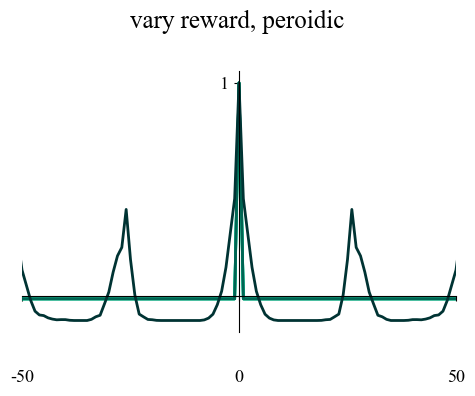

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch15, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep15 saved
total reward per trial: 183.32234121714234


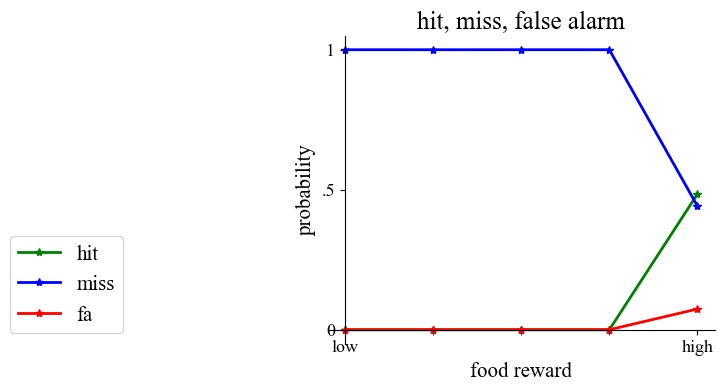

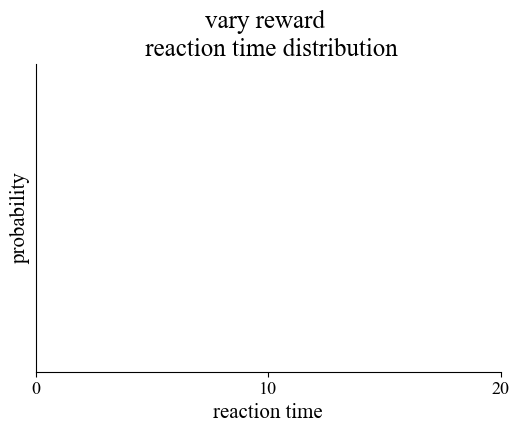

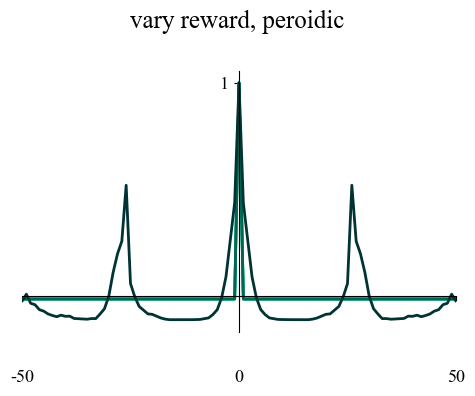

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch16, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep16 saved
total reward per trial: 446.17470502444587


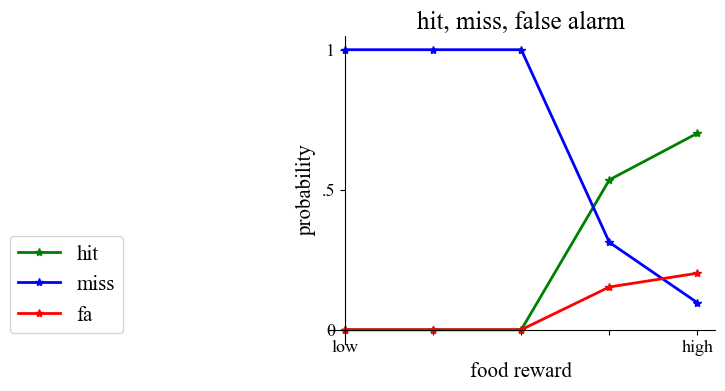

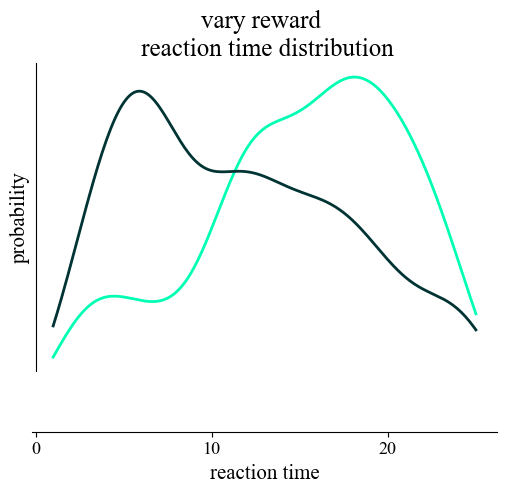

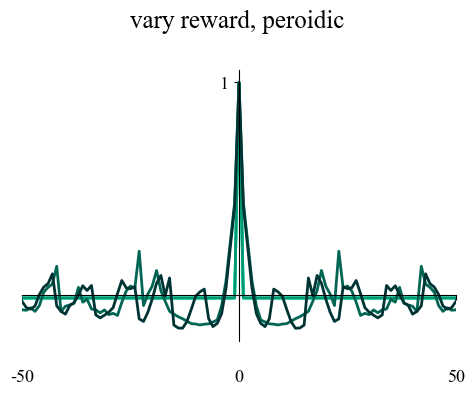

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch17, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep17 saved
total reward per trial: 0.0


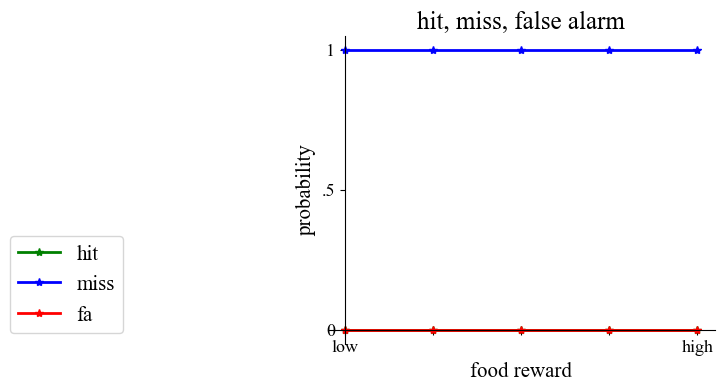

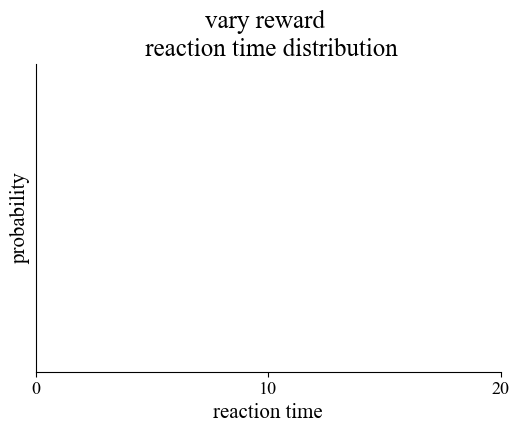

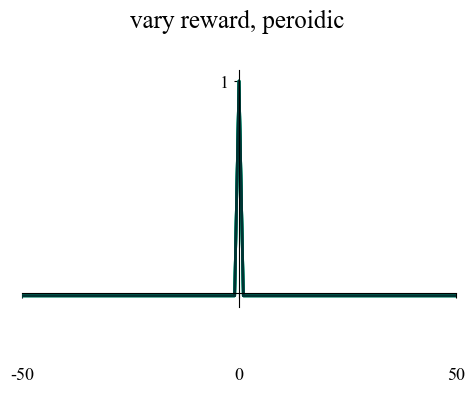

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch18, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep18 saved
total reward per trial: 461.1514027779713


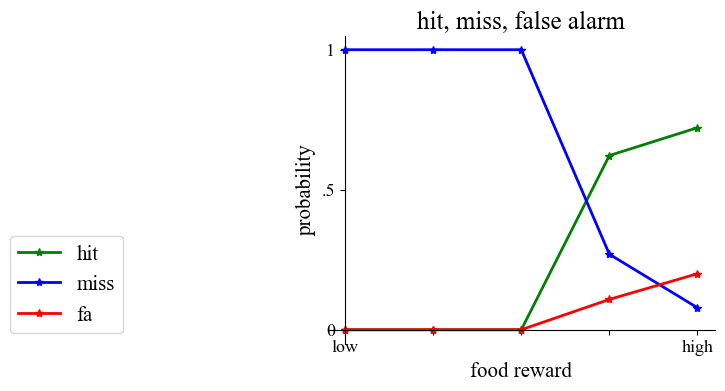

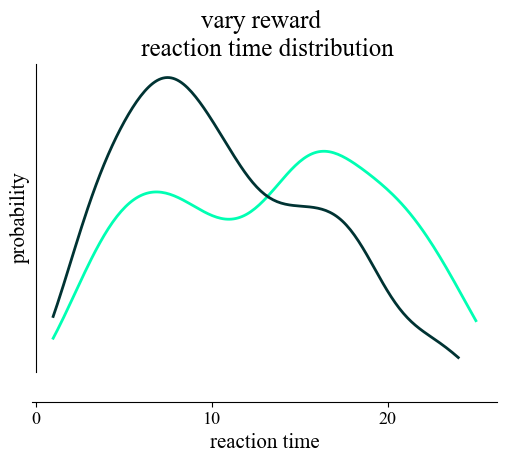

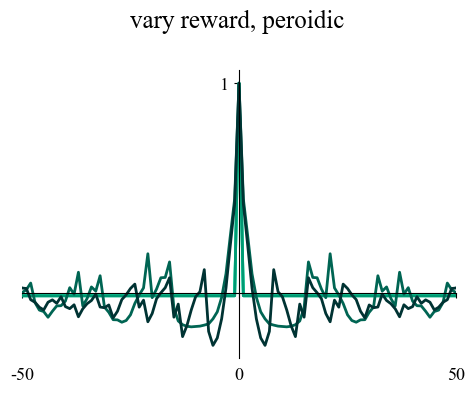

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch19, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep19 saved
total reward per trial: 0.0


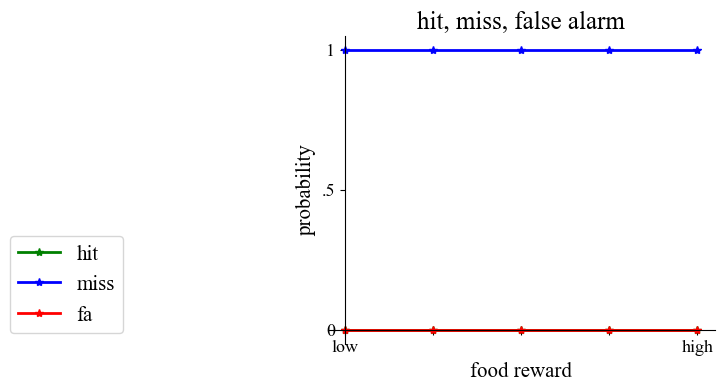

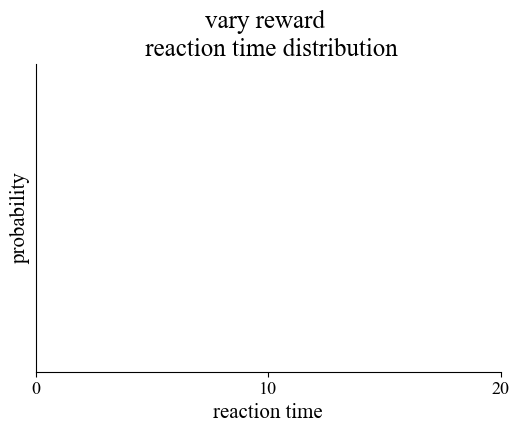

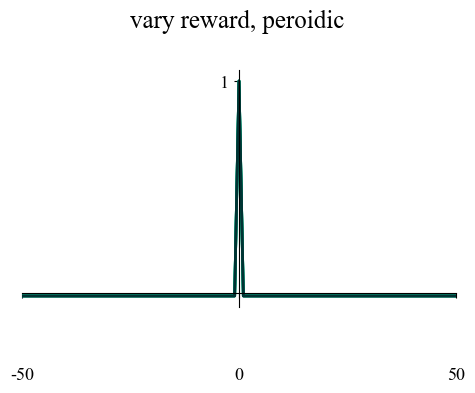

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch20, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep20 saved
total reward per trial: 0.0


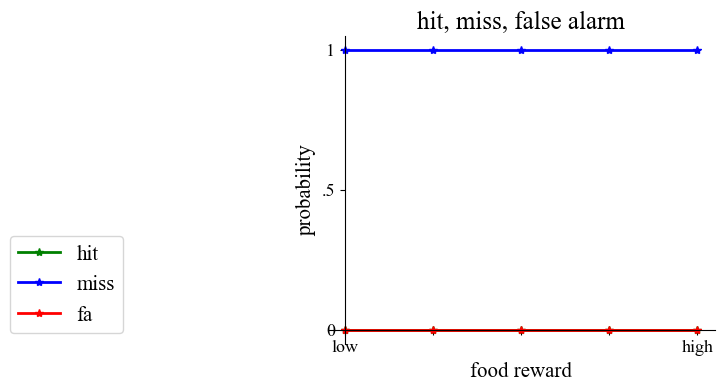

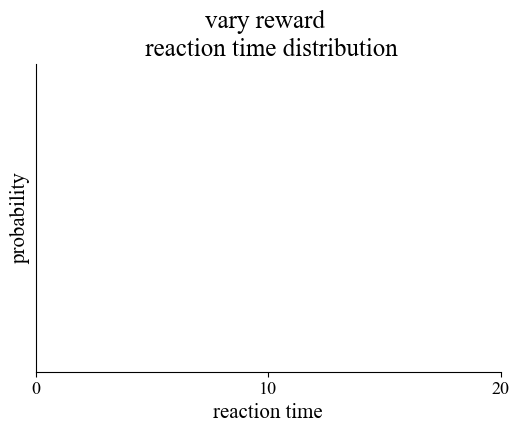

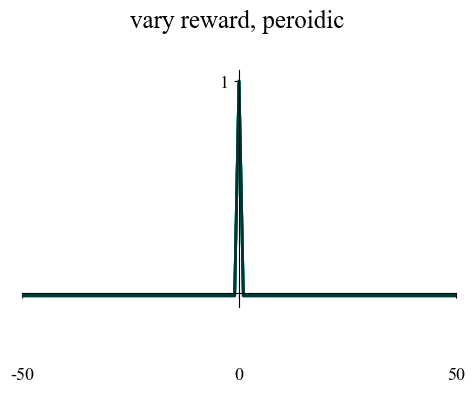

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch21, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep21 saved
total reward per trial: 213.51334477721534


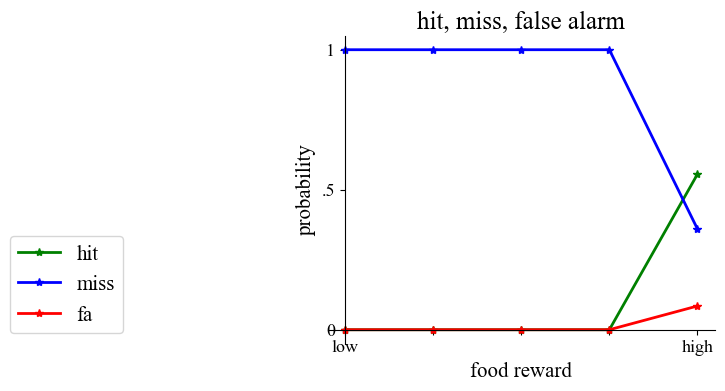

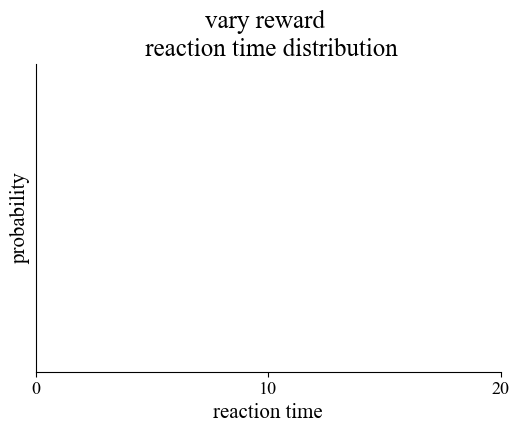

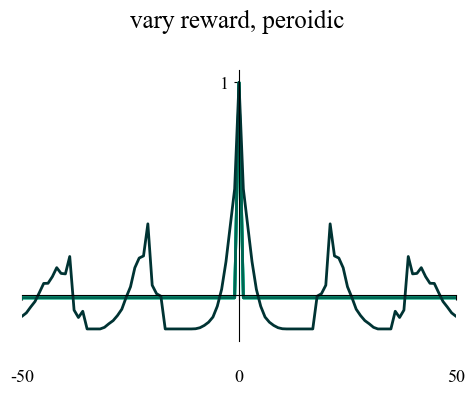

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch22, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep22 saved
total reward per trial: 652.1989901903944


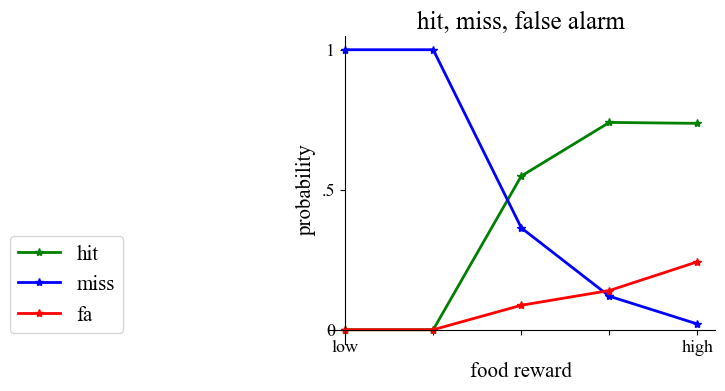

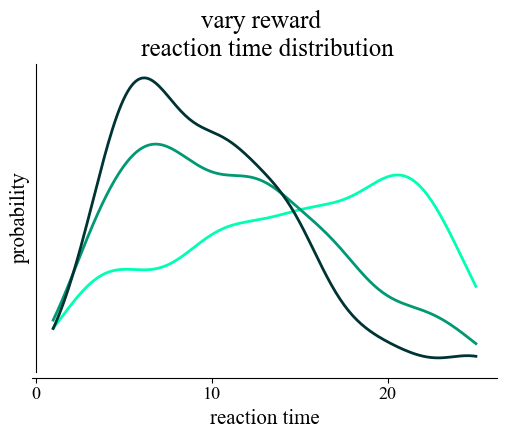

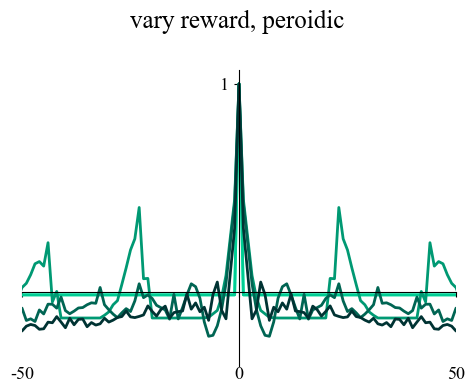

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch23, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep23 saved
total reward per trial: 264.0074388704095


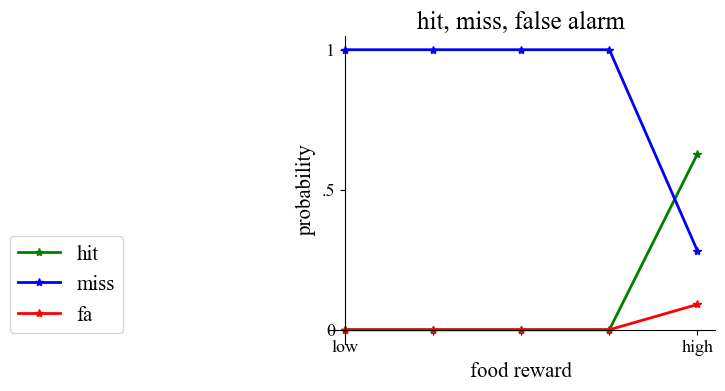

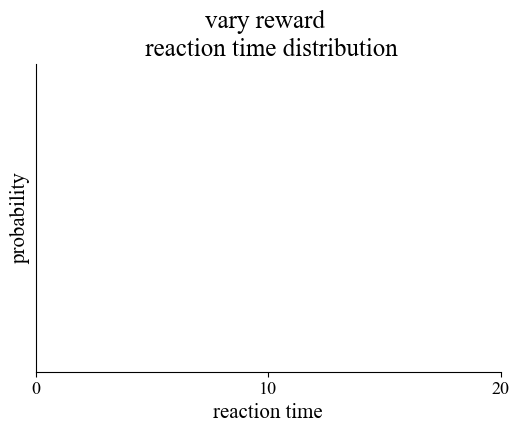

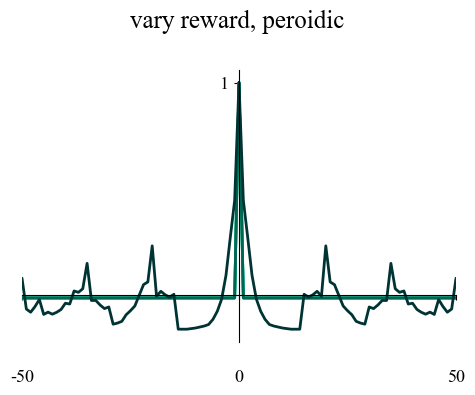

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch24, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep24 saved
total reward per trial: 249.50166779472895


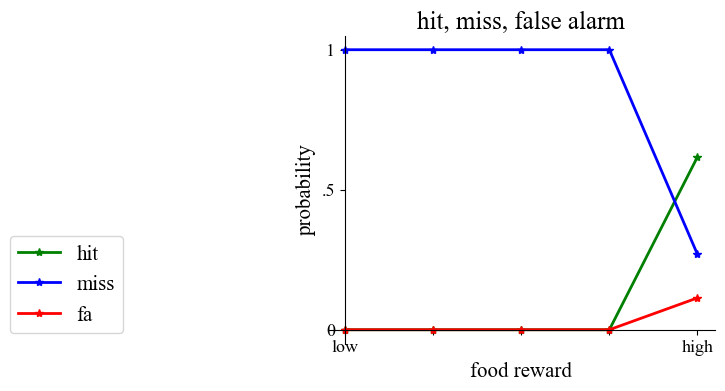

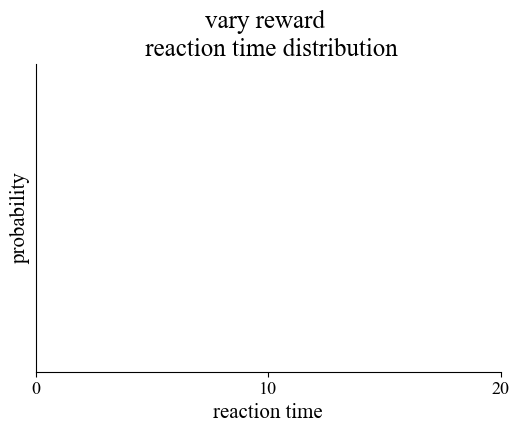

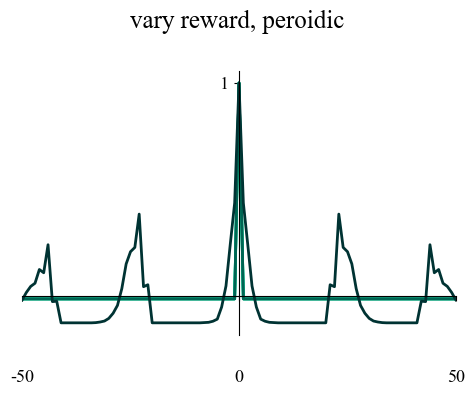

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch25, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep25 saved
total reward per trial: 221.41899367704949


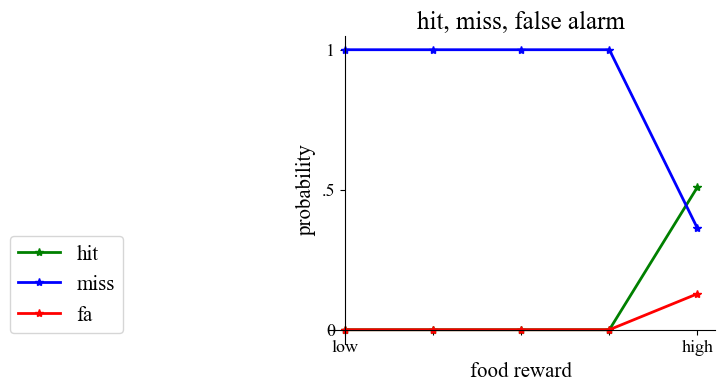

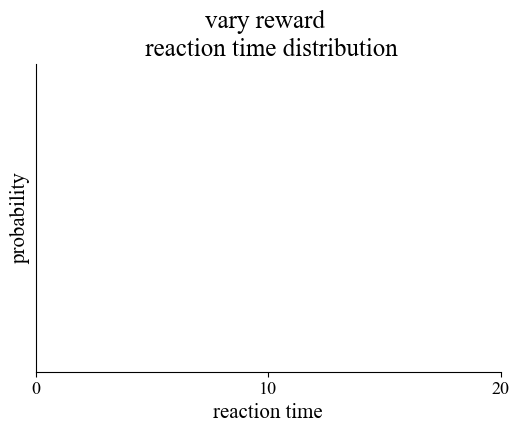

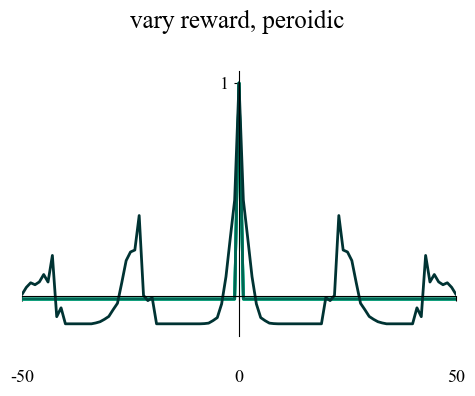

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch26, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep26 saved
total reward per trial: 213.0351809714611


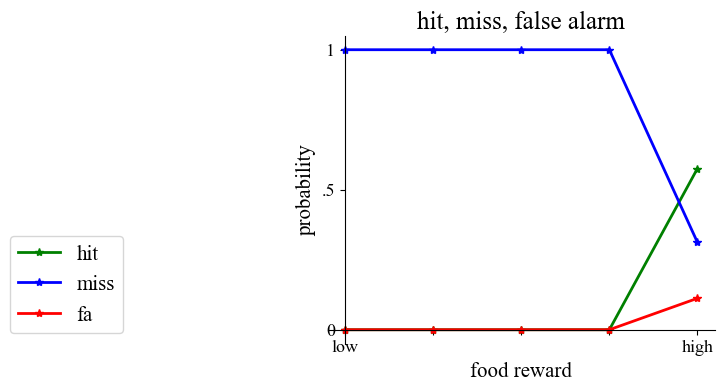

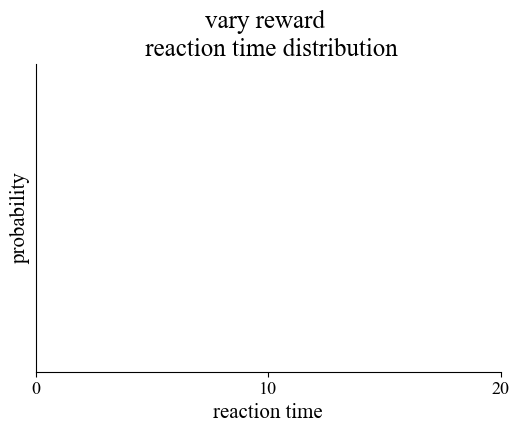

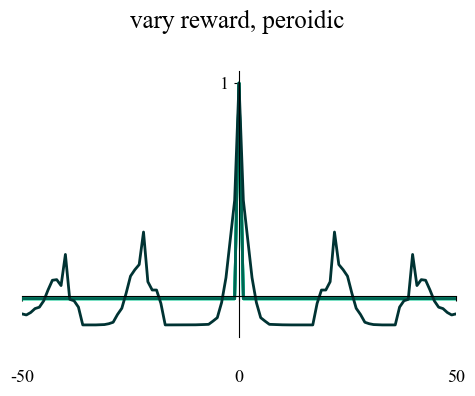

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch27, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep27 saved
total reward per trial: 195.00935784486362


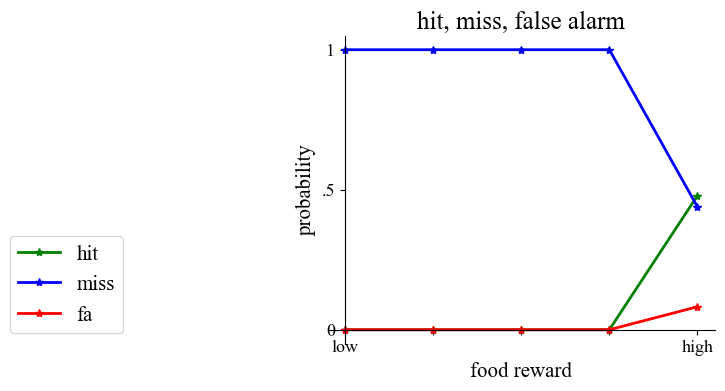

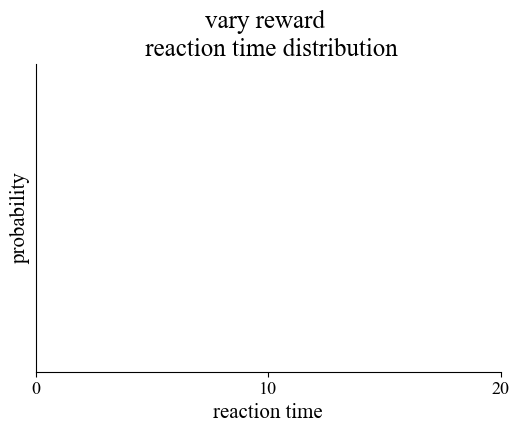

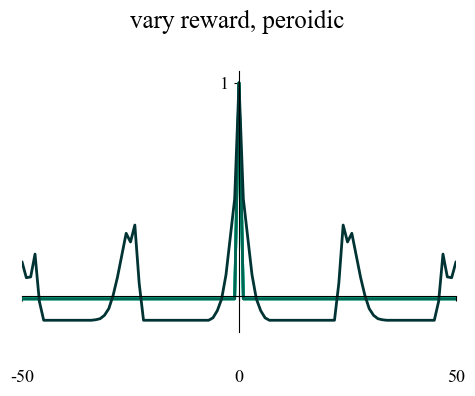

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch28, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep28 saved
total reward per trial: 366.1716433893168


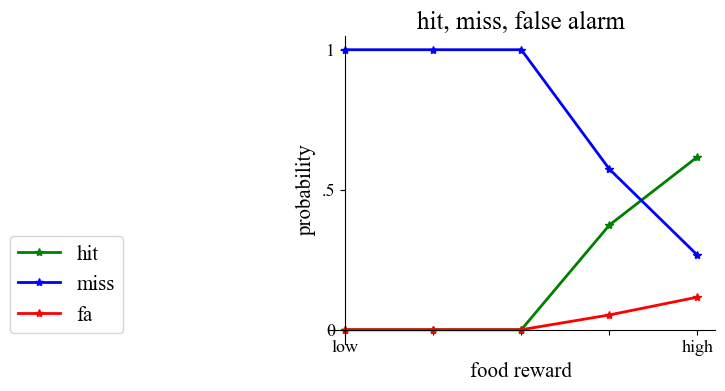

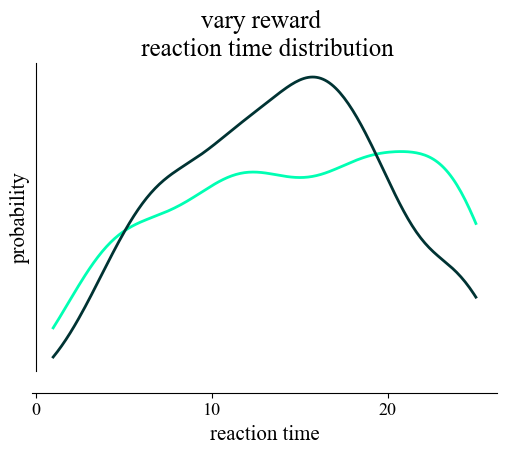

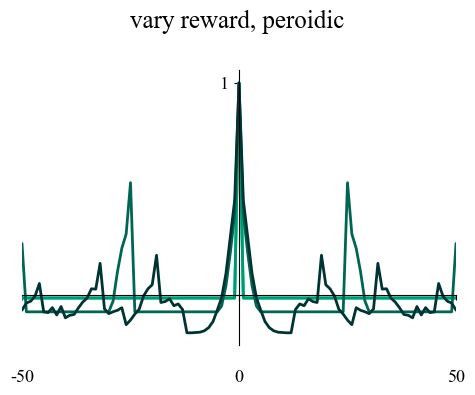

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch29, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep29 saved
total reward per trial: 385.45741850131986


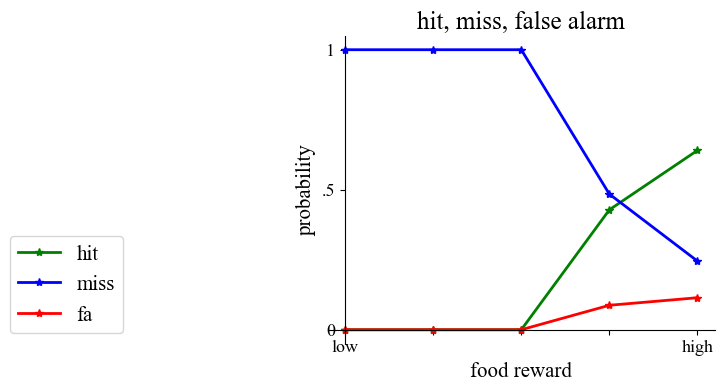

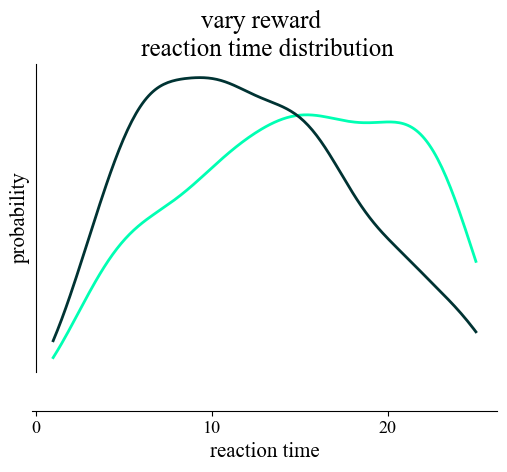

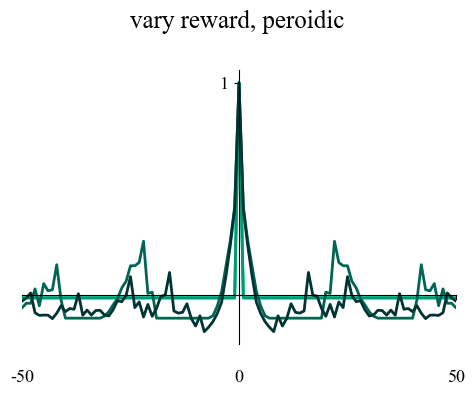

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch30, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep30 saved
total reward per trial: 433.1060861807504


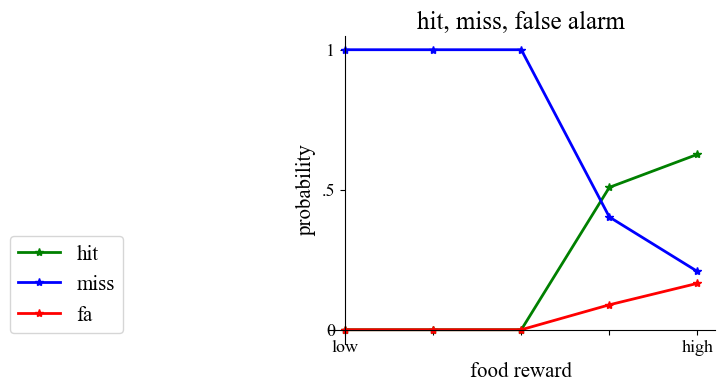

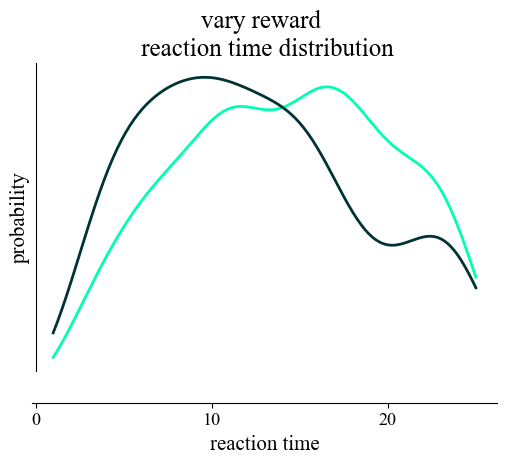

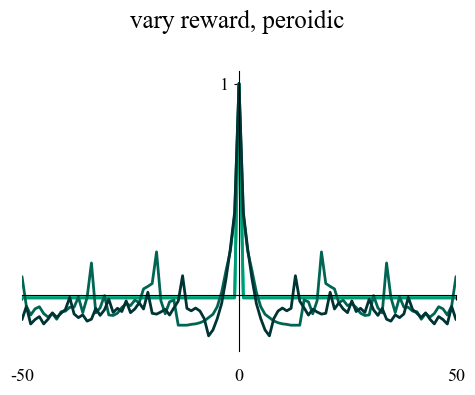

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch31, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep31 saved
total reward per trial: 435.5830472573661


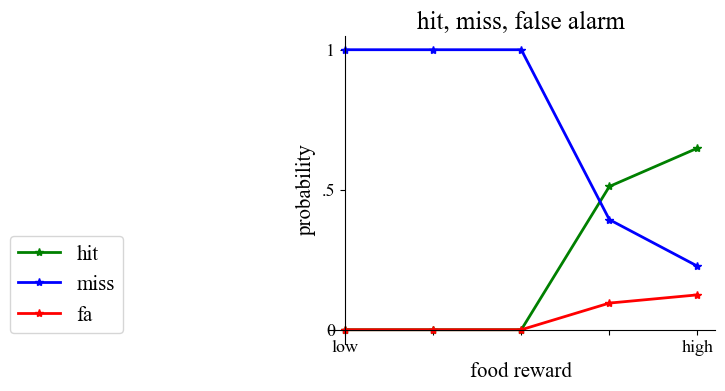

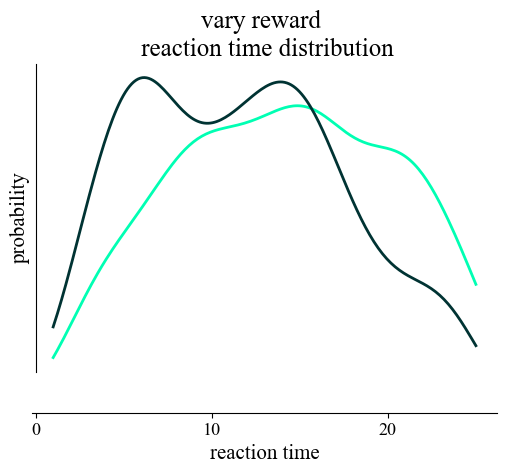

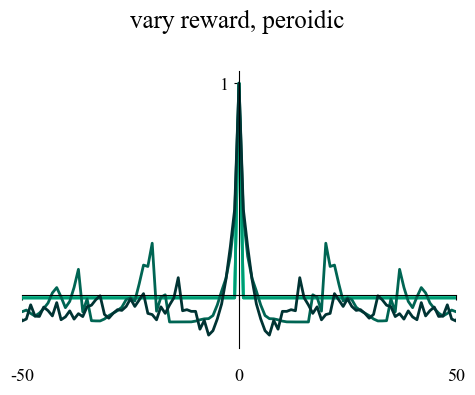

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch32, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep32 saved
total reward per trial: 343.7495411636818


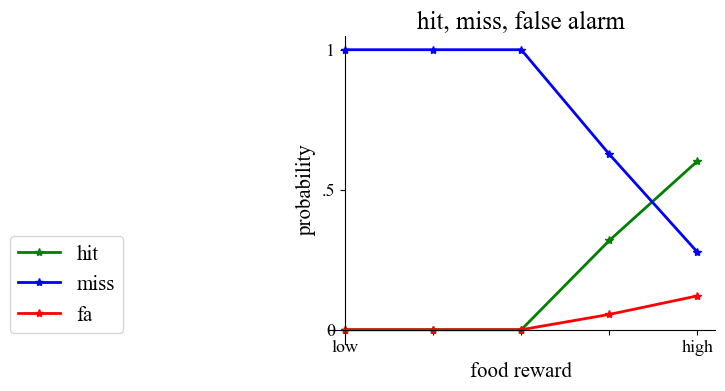

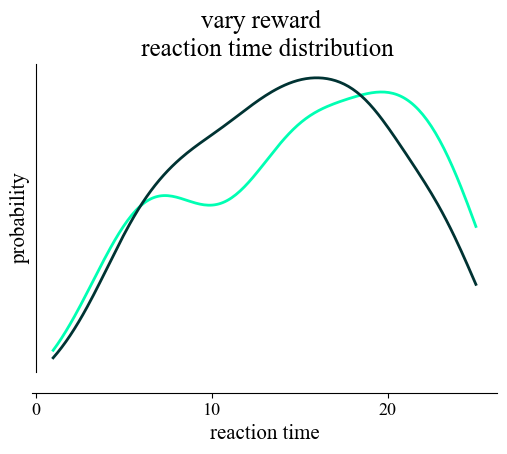

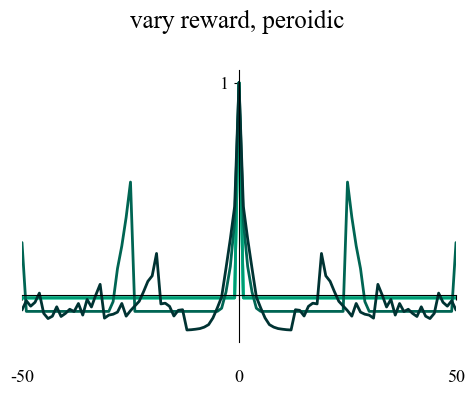

In [19]:
# for iepoch in range(n_epoch, n_epoch+10):
for iepoch in range(0, n_epoch):

    # training ----------------
    for node in node_list:
        for p1p2 in plist:
            thismodel = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch}'
        
            task = AFtask(spec={'agent':
                            {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]},
                            'experiment': {'no_signal_nodes': node}})
            task.set_param(env_param)
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            task.obs_certainity_possible = p1p2

            # train
            if iepoch == 0:
                model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                            clip_range=0.1, ent_coef=0.01)
            else:
                previous_model = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch-1}'
                model = PPO.load(f'ycstore/{previous_model}', env=taskbelief)
            model.learn(total_timesteps=epoch_size,)
            model.save(f'ycstore/{thismodel}')
            print(f'epoch{iepoch}, node{node}: yctore/{thismodel} saved')
            model = PPO.load(f'ycstore/{thismodel}', env=taskbelief) # test load

    # eval collection --------------------
    results=[]
    for inode, node in enumerate(node_list):
        for ip, p1p2 in enumerate(plist):
            task = AFtask(spec={'agent': 
                                        {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                        'experiment':{                              'no_signal_nodes':node}})
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            task.obs_certainity_possible = p1p2
            thismodel = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch}'
            model = PPO.load(f'ycstore/{thismodel}')

            def eval_wrapper(a):
                episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                        num_steps=100000, deterministic=True)
                return episode

            with multiprocess.Pool(processes=8) as pool:
                all_episode_data = pool.map(eval_wrapper, range(no_episodes))
            
            for episode in all_episode_data:
                # process
                episode['inode'] = inode
                episode['ip'] = ip
                episode['at_times'] = np.where(
                    np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
                episode['at_seq'] = [float(elt[1])
                                    for elt in episode['actions']]
                if episode['actions'][-1][0] == 1:
                    episode['licktime'] = int(len(episode['states']))
                else:
                    episode['lick_licktimetime'] = -1
                episode['trial_len'] = len(episode['actions'])

                results.append(episode)

    df = pd.DataFrame(results)
    print(f'total reward per trial: {sum(np.concatenate(df.rewards.to_numpy()))/len(df)}')

    hit_reaction_plot(df,'energy')


/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch33, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep33 saved
total reward per trial: 400.6727892498587


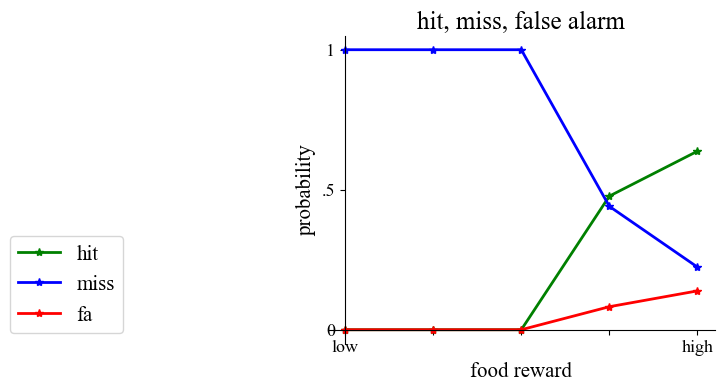

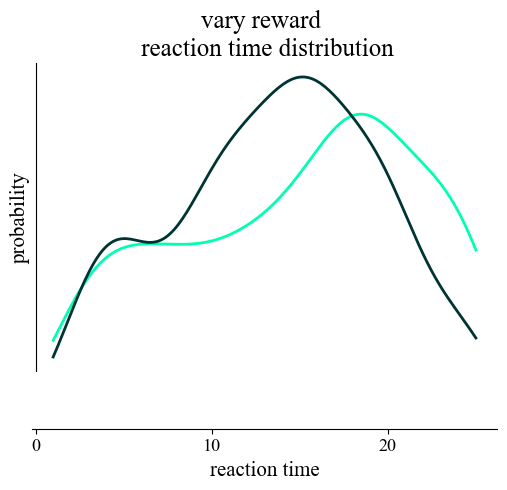

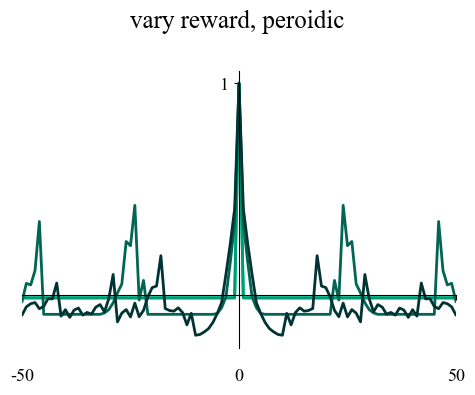

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch34, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep34 saved
total reward per trial: 339.65233987149065


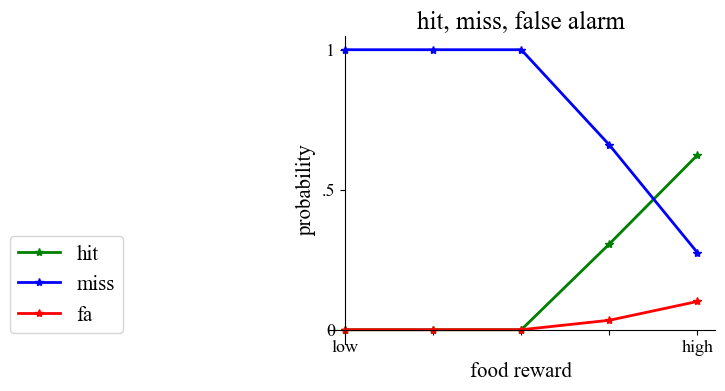

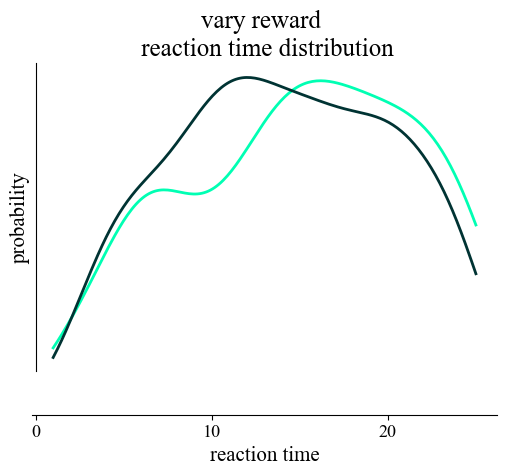

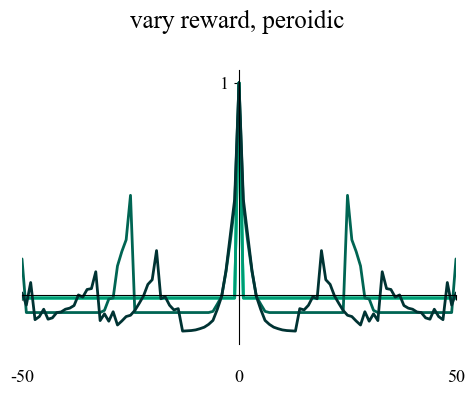

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch35, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep35 saved
total reward per trial: 344.0563885644884


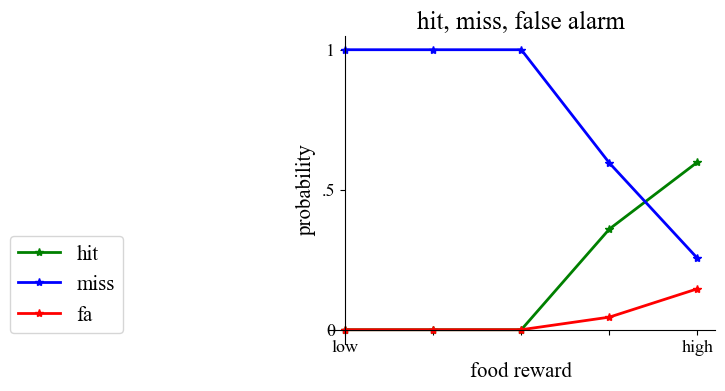

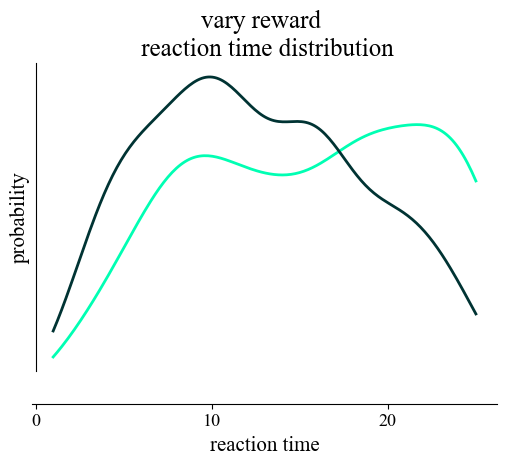

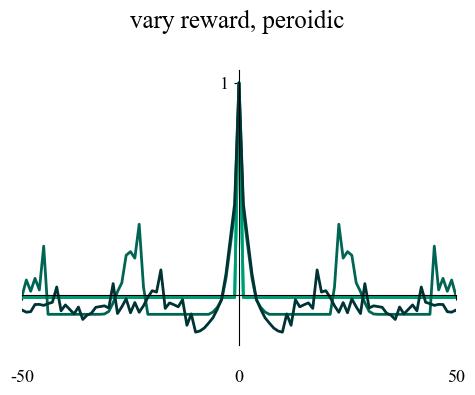

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch36, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep36 saved
total reward per trial: 129.44008552873248


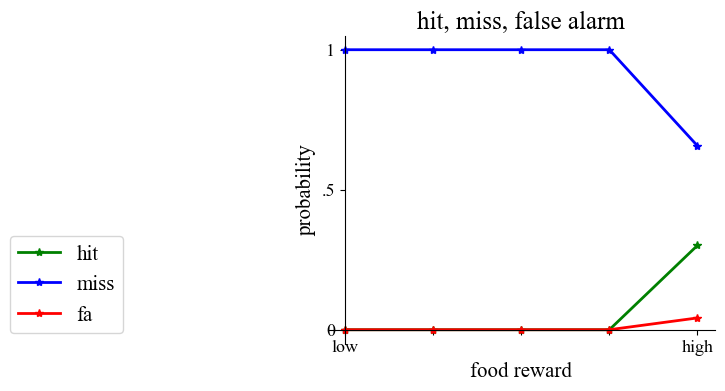

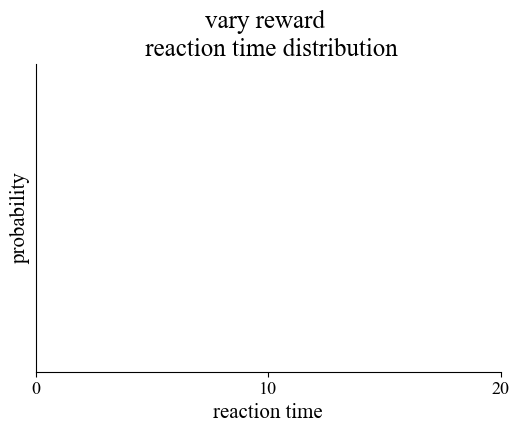

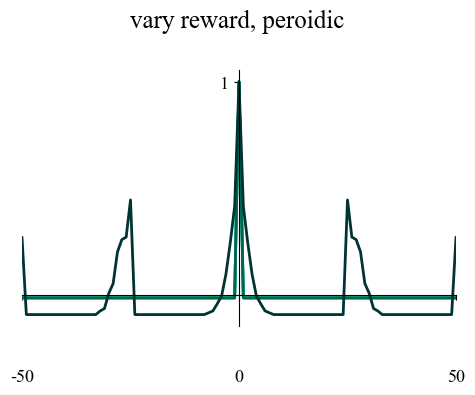

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch37, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep37 saved
total reward per trial: 435.9238343260425


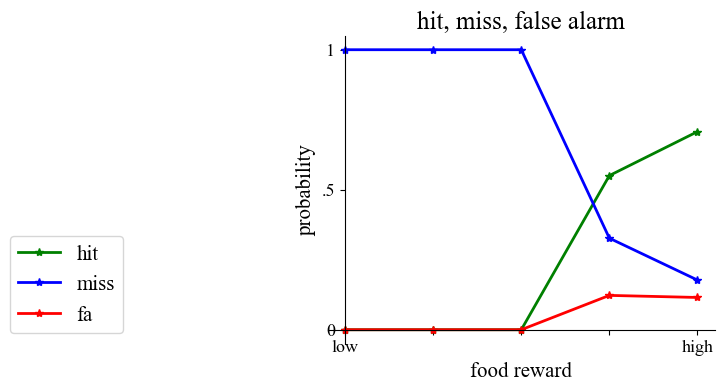

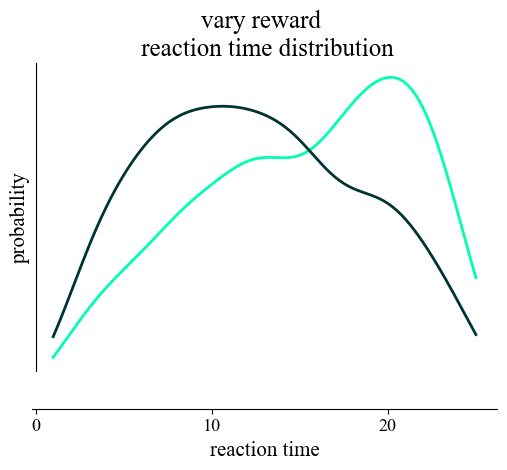

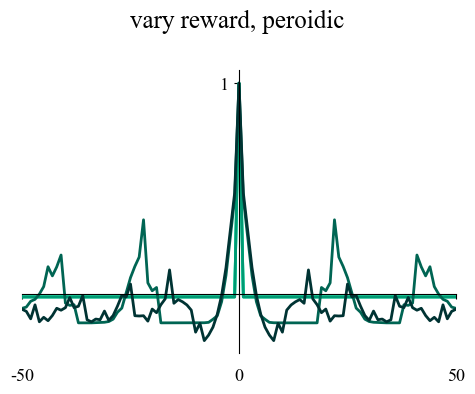

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch38, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep38 saved
total reward per trial: 310.27207146495687


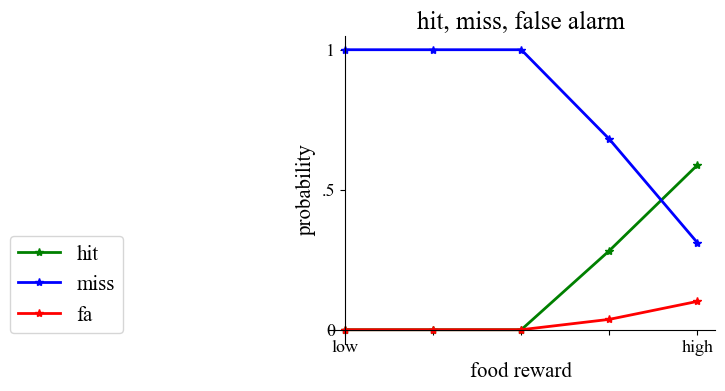

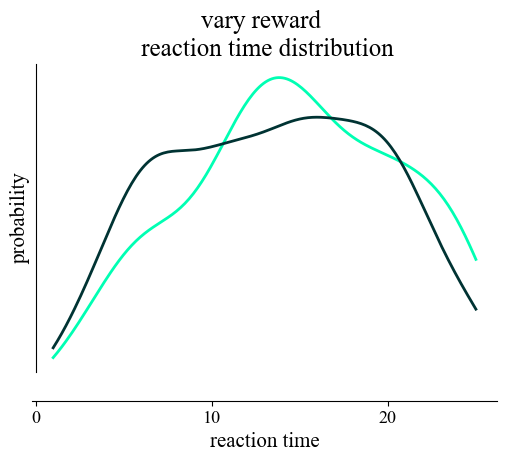

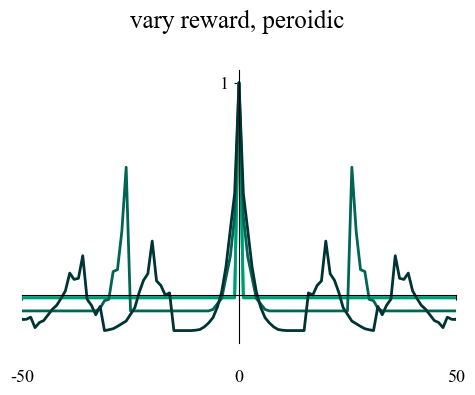

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch39, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep39 saved
total reward per trial: 216.74548669491915


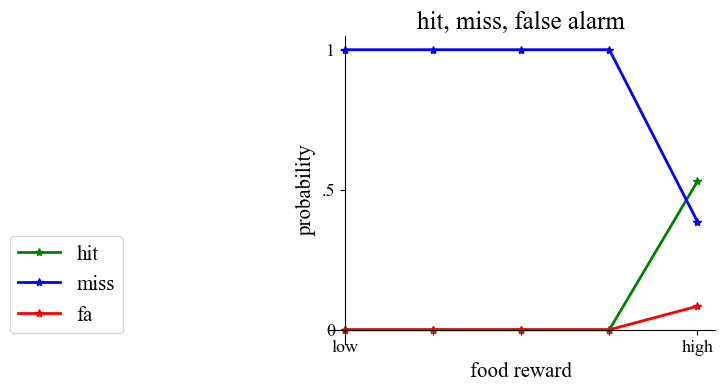

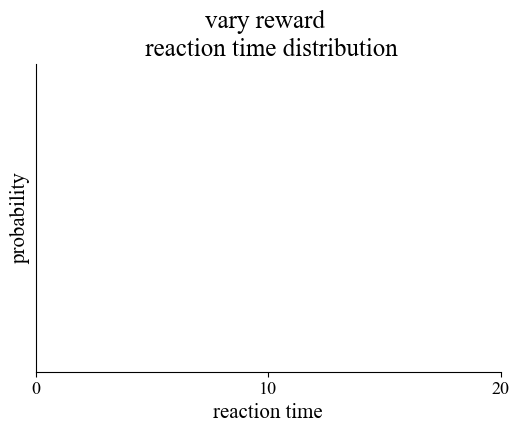

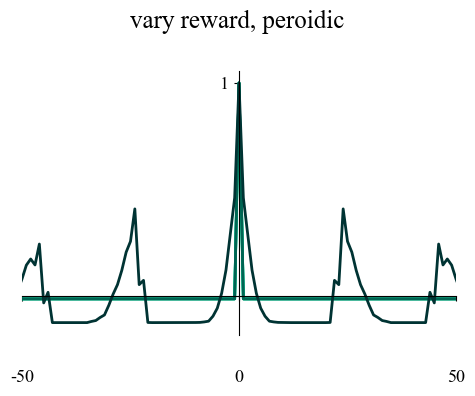

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch40, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep40 saved
total reward per trial: 665.4341792385651


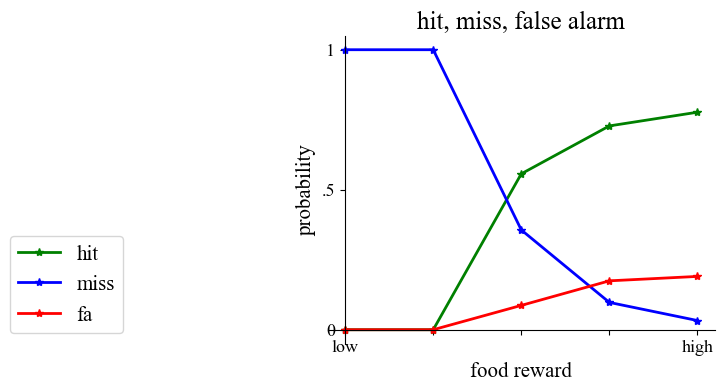

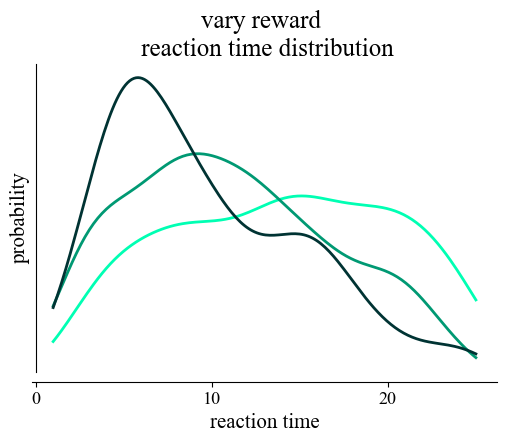

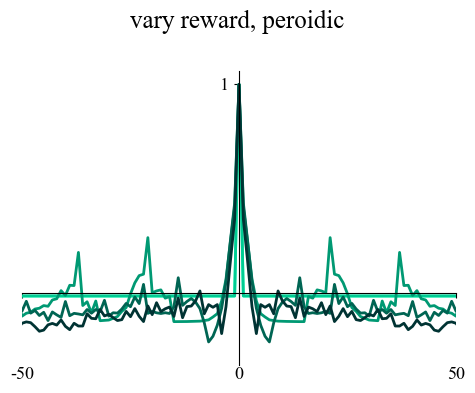

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch41, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep41 saved
total reward per trial: 578.4713994848363


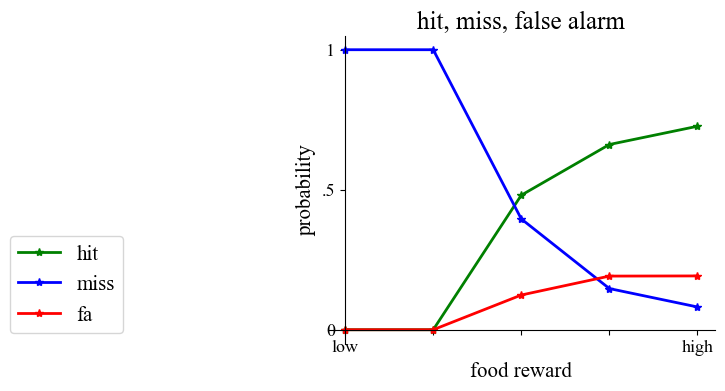

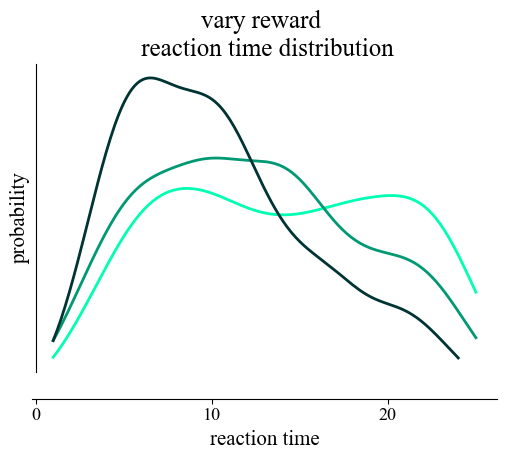

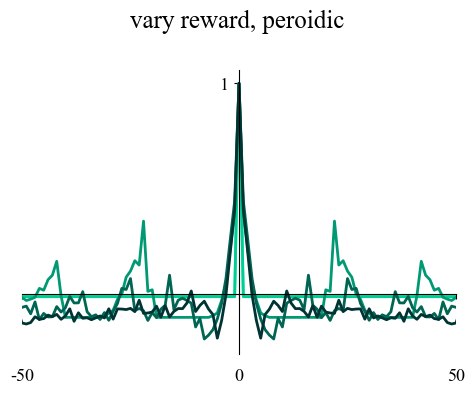

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch42, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep42 saved
total reward per trial: 563.1288144649817


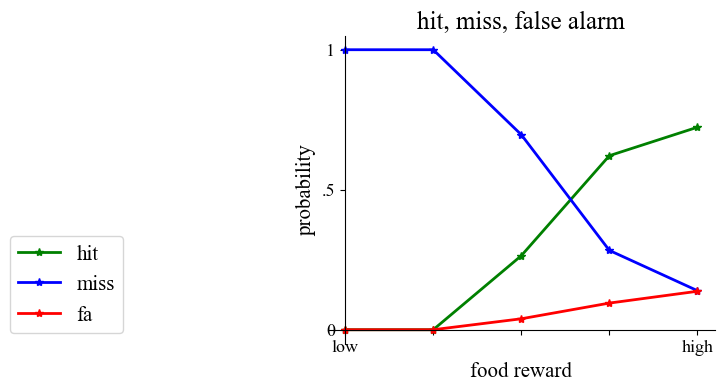

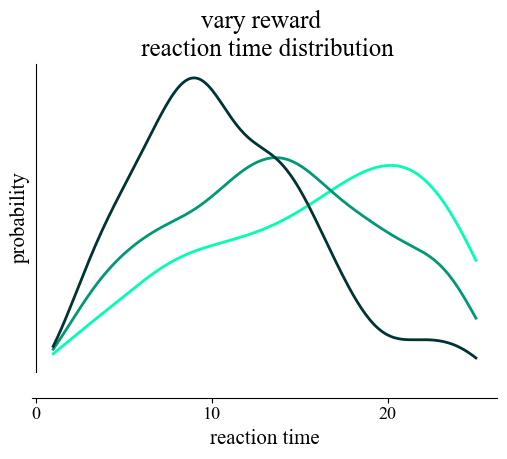

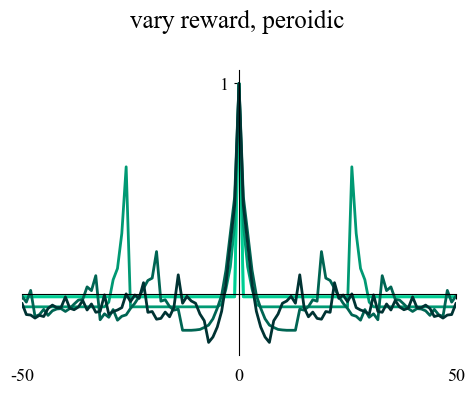

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch43, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep43 saved
total reward per trial: 627.4888268166595


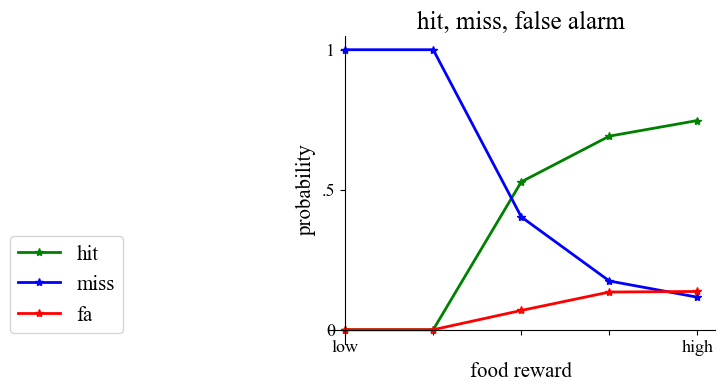

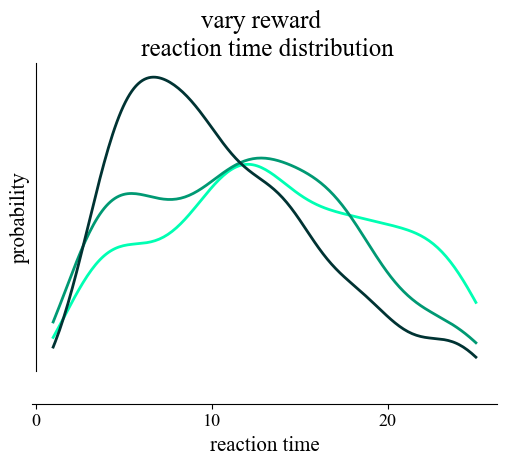

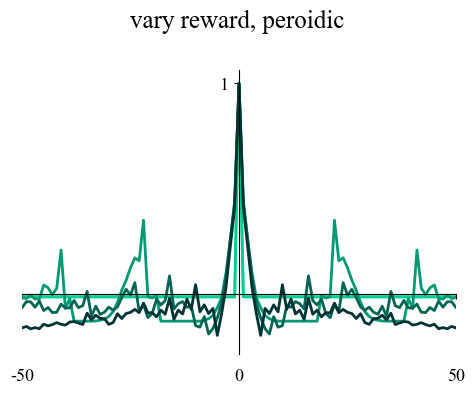

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch44, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep44 saved
total reward per trial: 551.1841306179825


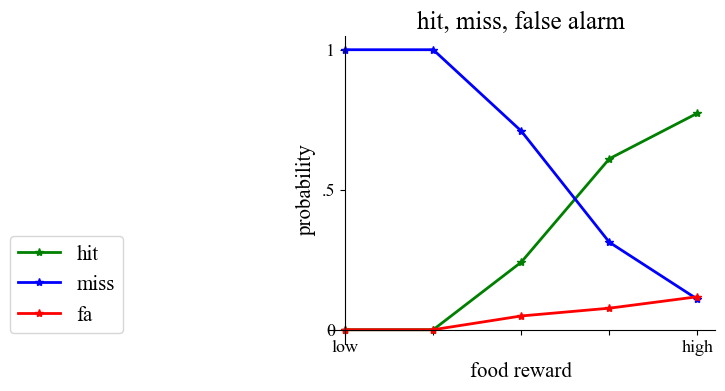

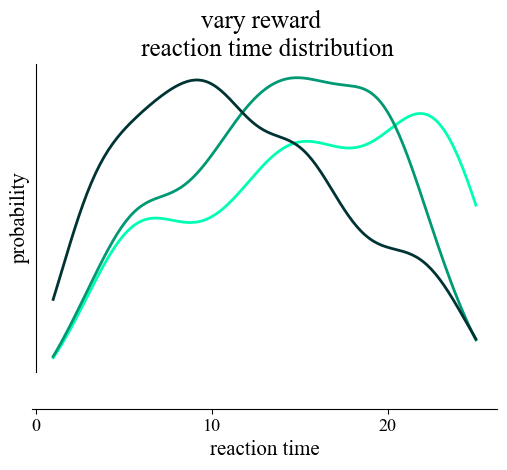

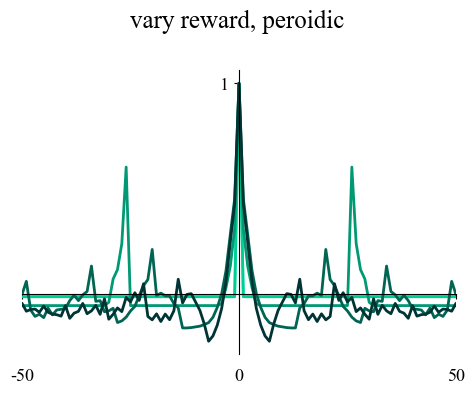

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch45, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep45 saved
total reward per trial: 678.9391908792246


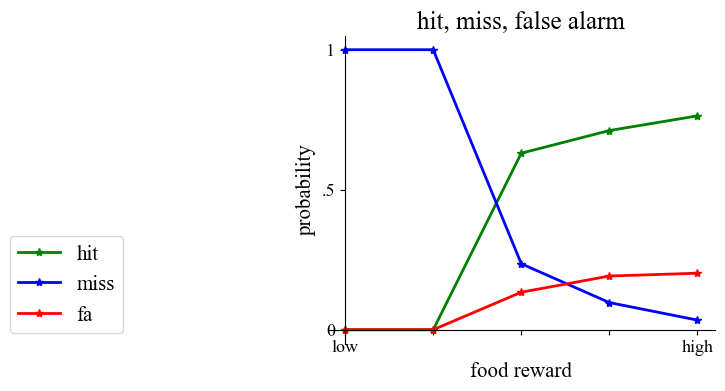

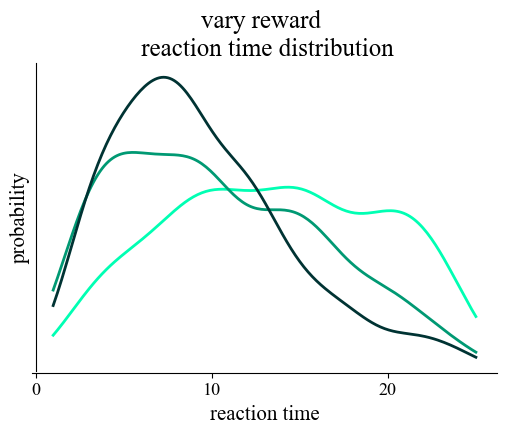

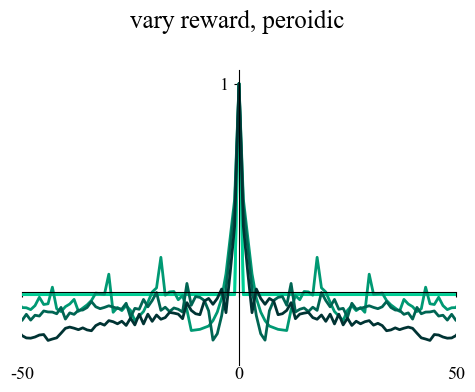

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch46, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep46 saved
total reward per trial: 762.4589248205217


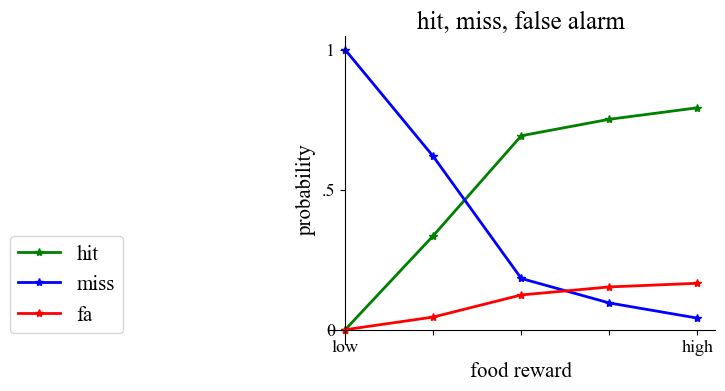

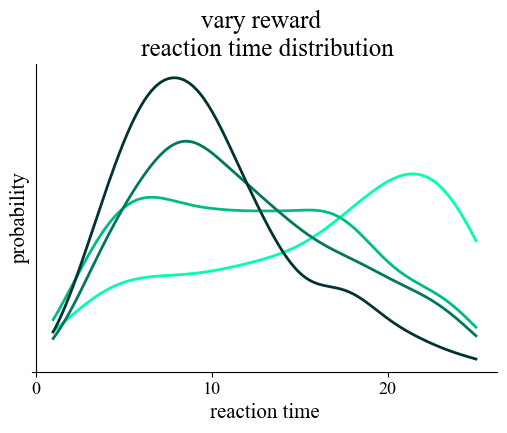

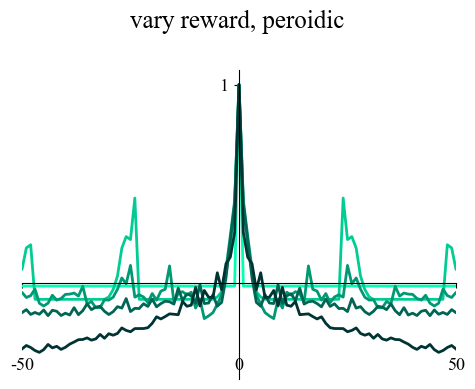

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch47, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep47 saved
total reward per trial: 542.0895651796063


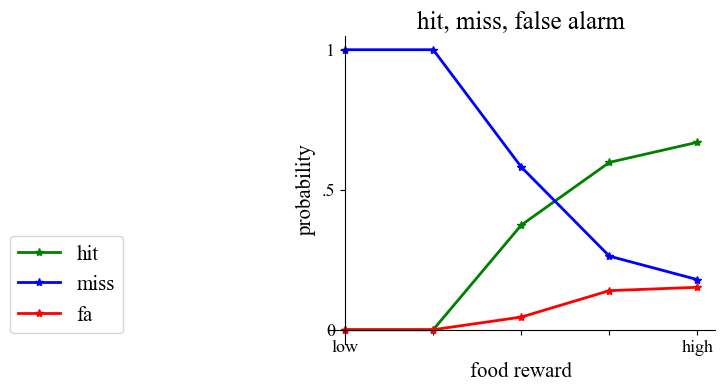

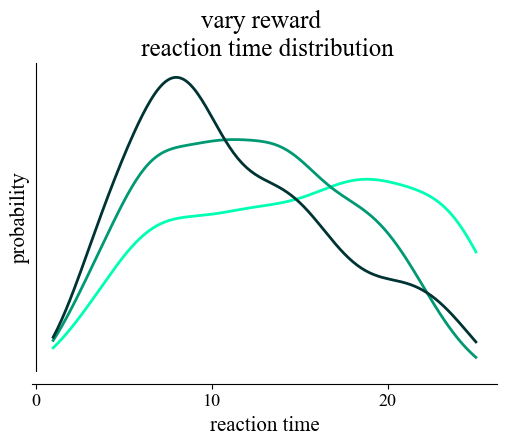

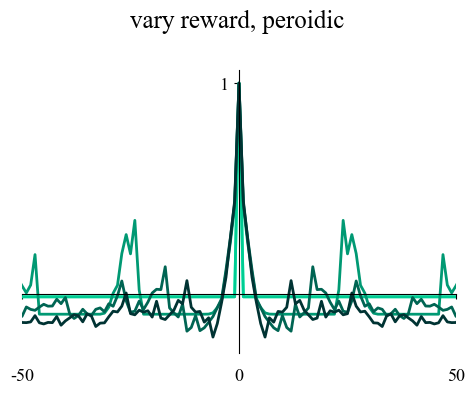

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch48, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep48 saved
total reward per trial: 562.6734845059368


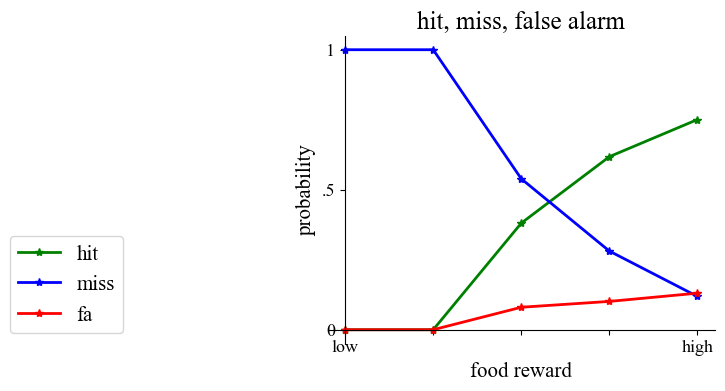

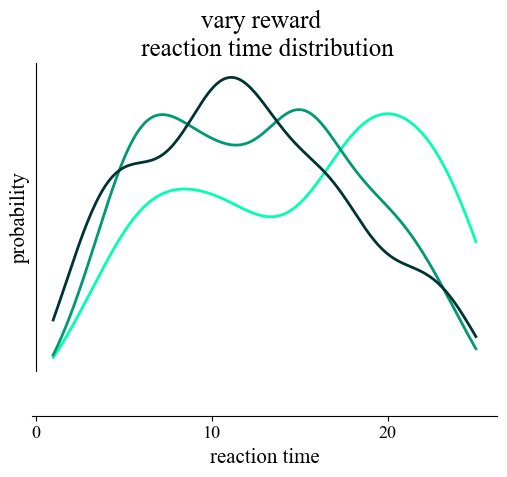

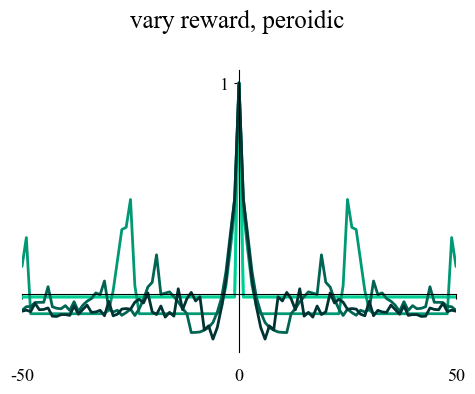

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch49, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep49 saved
total reward per trial: 413.9320400213965


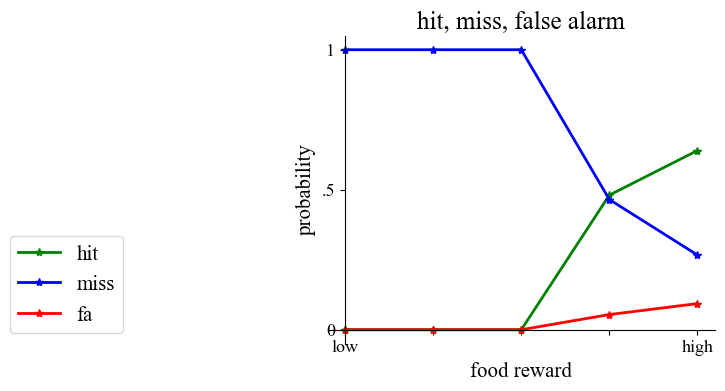

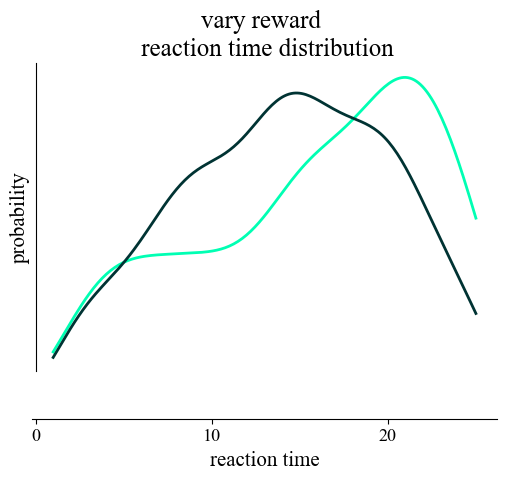

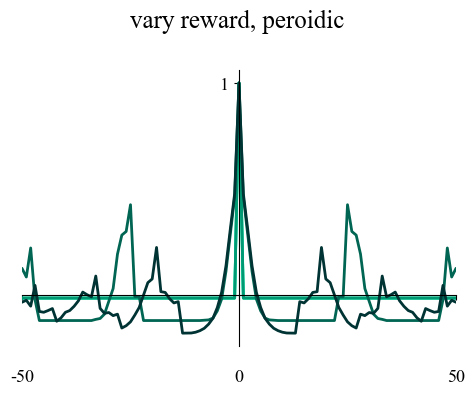

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch50, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep50 saved
total reward per trial: 540.3889230696109


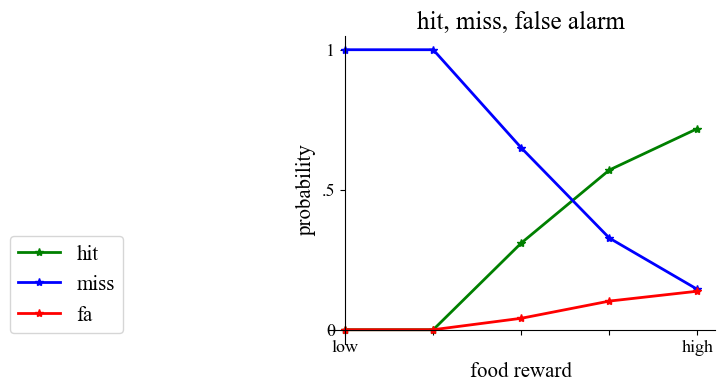

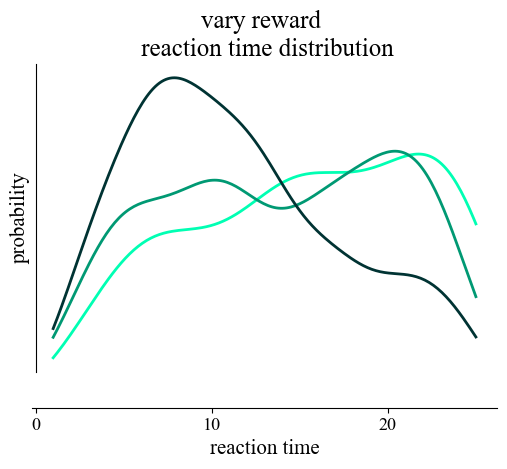

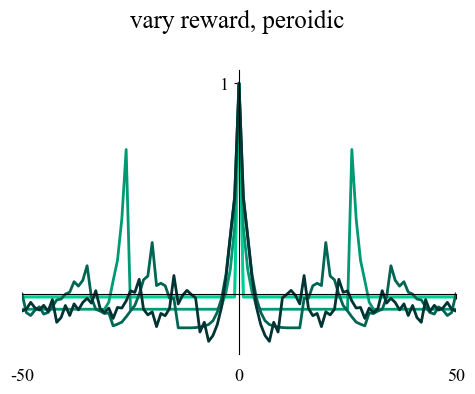

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch51, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep51 saved
total reward per trial: 639.3829823914629


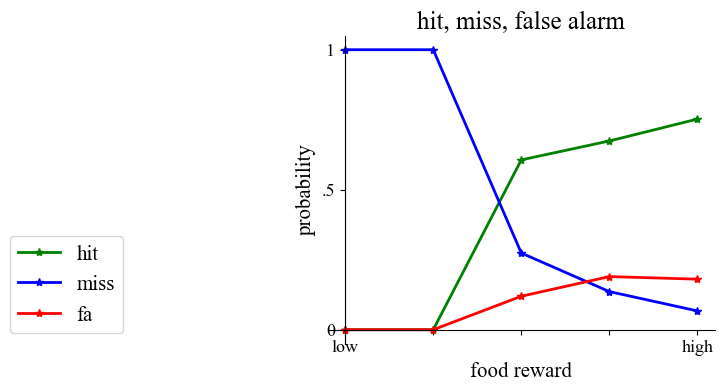

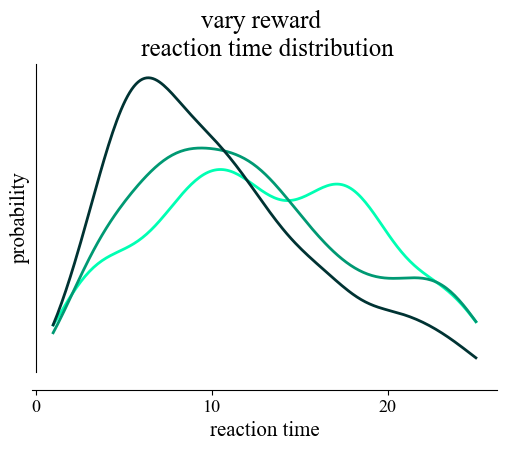

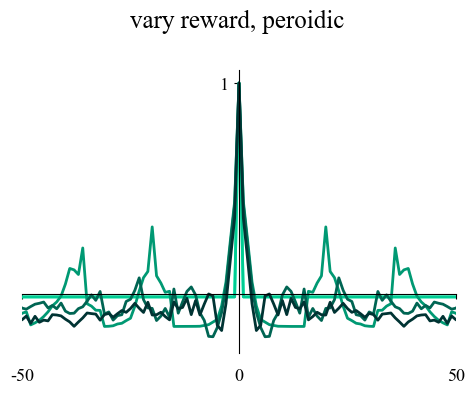

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch52, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep52 saved
total reward per trial: 663.0918268113492


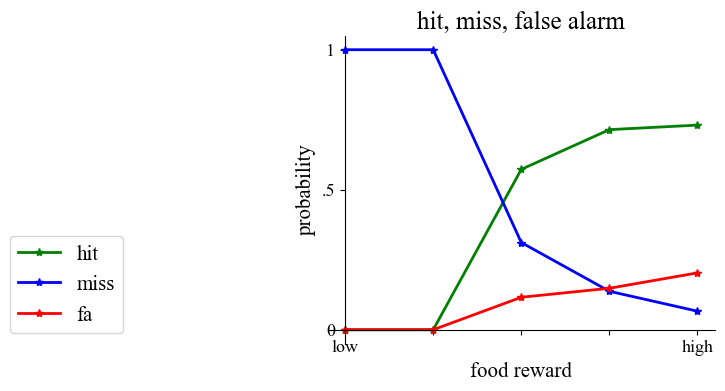

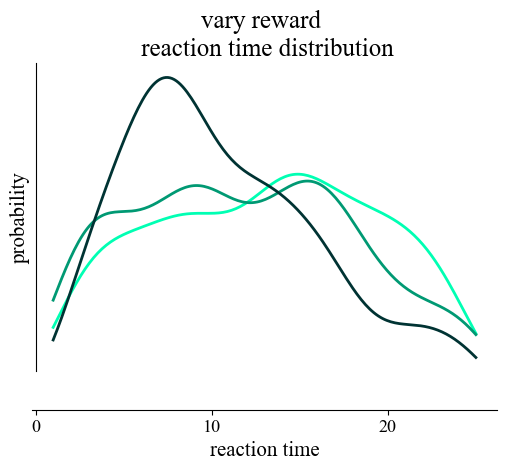

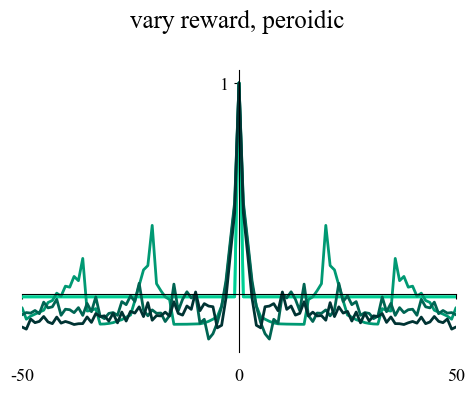

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch53, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep53 saved
total reward per trial: 650.6388158313882


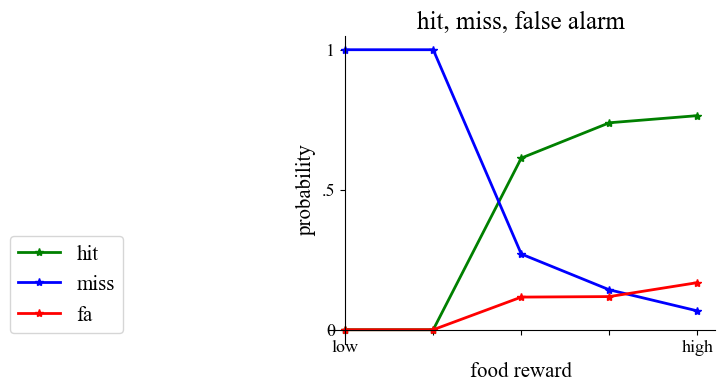

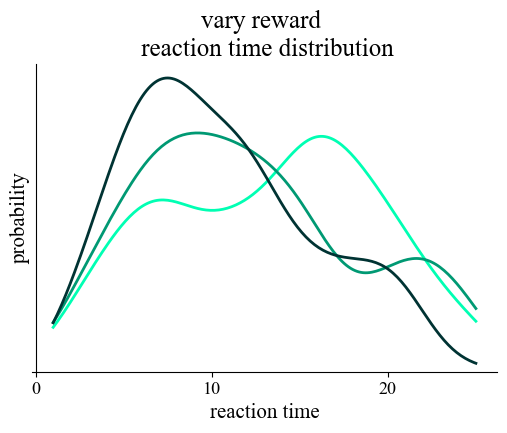

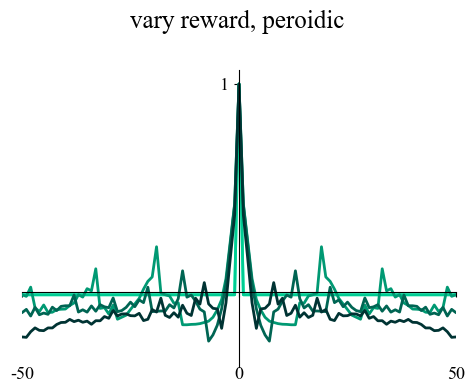

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch54, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep54 saved
total reward per trial: 523.4837875658069


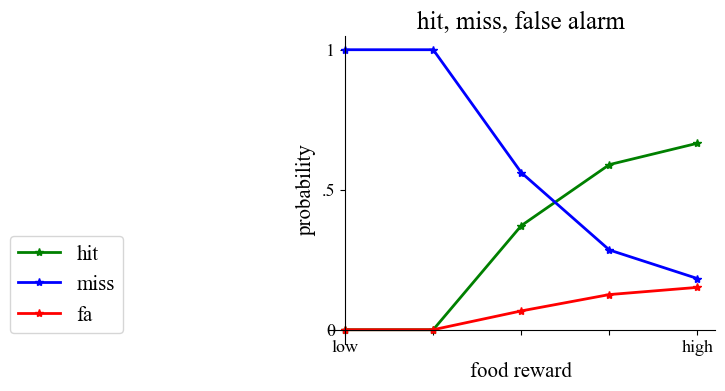

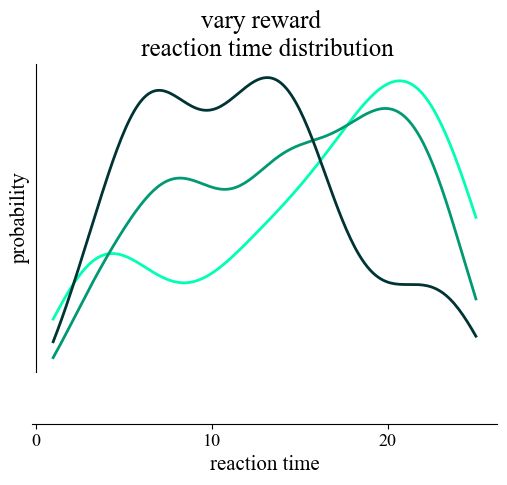

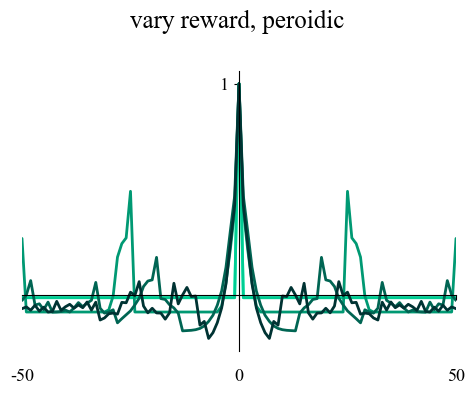

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch55, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep55 saved
total reward per trial: 383.3251309414175


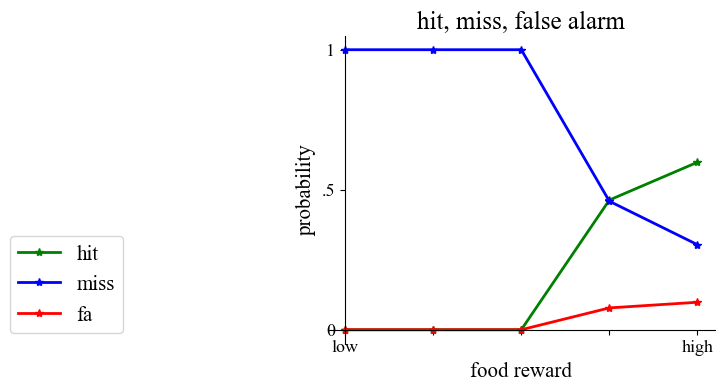

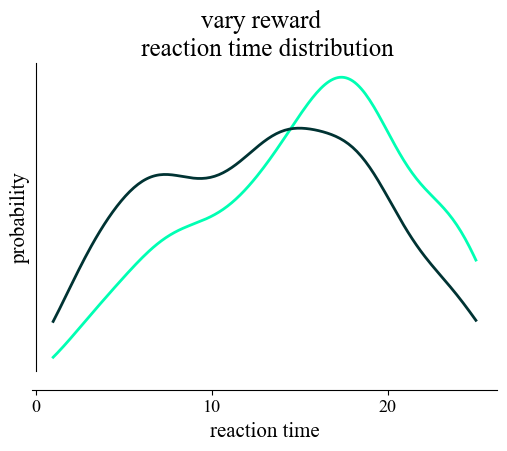

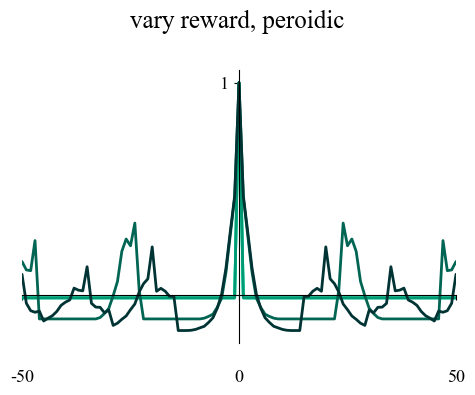

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch56, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep56 saved
total reward per trial: 583.7715904195564


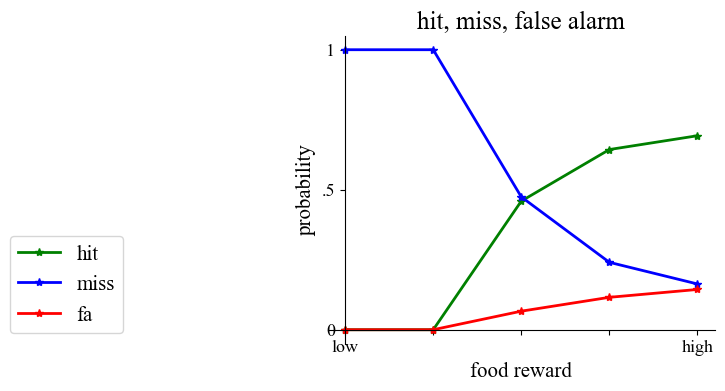

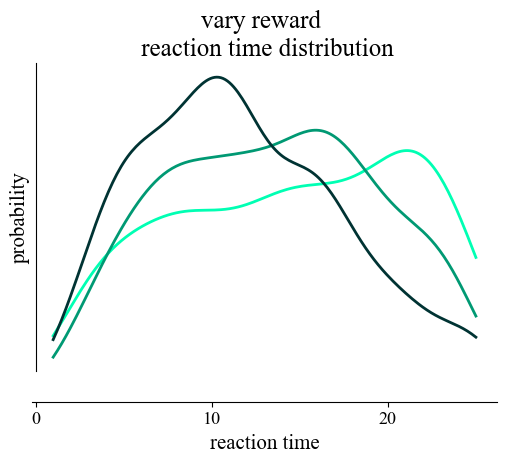

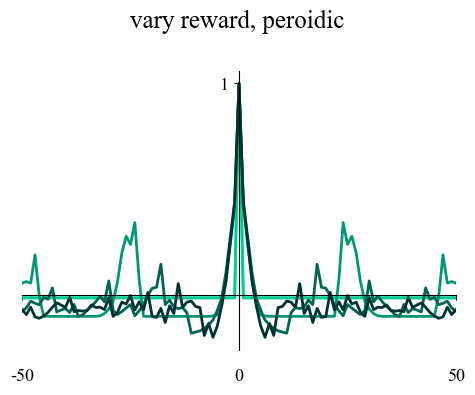

/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch57, node25: yctore/seed0_vary_reward_energyV6_n25_p[0.5 0.7]_ep57 saved


KeyboardInterrupt: 

In [20]:
# for iepoch in range(n_epoch, n_epoch+10):
for iepoch in range(n_epoch, 111):

    # training ----------------
    for node in node_list:
        for p1p2 in plist:
            thismodel = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch}'
        
            task = AFtask(spec={'agent':
                            {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]},
                            'experiment': {'no_signal_nodes': node}})
            task.set_param(env_param)
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            task.obs_certainity_possible = p1p2

            # train
            if iepoch == 0:
                model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                            clip_range=0.1, ent_coef=0.01)
            else:
                previous_model = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch-1}'
                model = PPO.load(f'ycstore/{previous_model}', env=taskbelief)
            model.learn(total_timesteps=epoch_size,)
            model.save(f'ycstore/{thismodel}')
            print(f'epoch{iepoch}, node{node}: yctore/{thismodel} saved')
            model = PPO.load(f'ycstore/{thismodel}', env=taskbelief) # test load

    # eval collection --------------------
    results=[]
    for inode, node in enumerate(node_list):
        for ip, p1p2 in enumerate(plist):
            task = AFtask(spec={'agent': 
                                        {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                        'experiment':{                              'no_signal_nodes':node}})
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            task.obs_certainity_possible = p1p2
            thismodel = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch}'
            model = PPO.load(f'ycstore/{thismodel}')

            def eval_wrapper(a):
                episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                        num_steps=100000, deterministic=True)
                return episode

            with multiprocess.Pool(processes=8) as pool:
                all_episode_data = pool.map(eval_wrapper, range(no_episodes))
            
            for episode in all_episode_data:
                # process
                episode['inode'] = inode
                episode['ip'] = ip
                episode['at_times'] = np.where(
                    np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
                episode['at_seq'] = [float(elt[1])
                                    for elt in episode['actions']]
                if episode['actions'][-1][0] == 1:
                    episode['licktime'] = int(len(episode['states']))
                else:
                    episode['lick_licktimetime'] = -1
                episode['trial_len'] = len(episode['actions'])

                results.append(episode)

    df = pd.DataFrame(results)
    print(f'total reward per trial: {sum(np.concatenate(df.rewards.to_numpy()))/len(df)}')

    hit_reaction_plot(df,'energy')


total reward per trial: 507.64321504800546


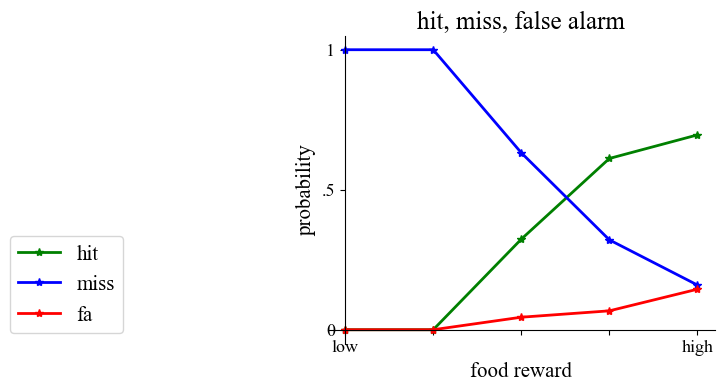

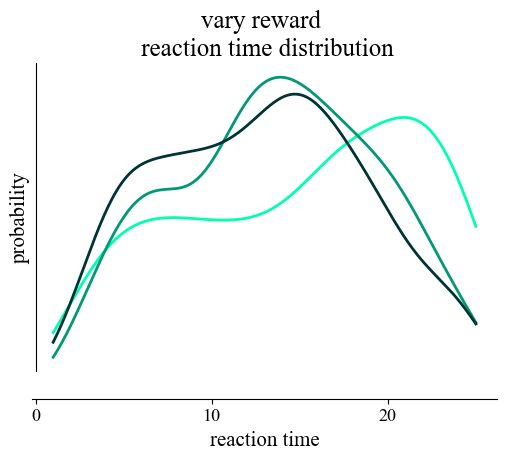

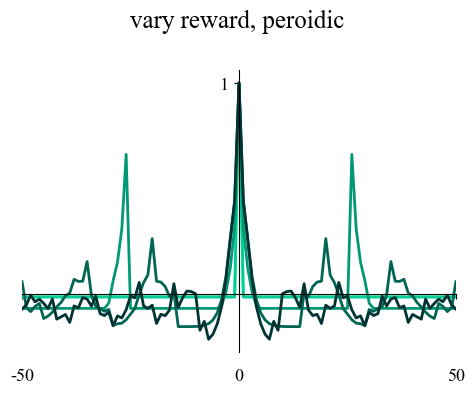

In [8]:
# for iepoch in range(n_epoch, n_epoch+10):
for iepoch in range(50,51):

    # eval collection --------------------
    results=[]
    for inode, node in enumerate(node_list):
        for ip, p1p2 in enumerate(plist):
            task = AFtask(spec={'agent': 
                                        {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                        'experiment':{                              'no_signal_nodes':node}})
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            task.obs_certainity_possible = p1p2
            thismodel = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch}'
            model = PPO.load(f'ycstore/{thismodel}')

            def eval_wrapper(a):
                episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                        num_steps=100000, deterministic=True)
                return episode

            with multiprocess.Pool(processes=8) as pool:
                all_episode_data = pool.map(eval_wrapper, range(no_episodes))
            
            for episode in all_episode_data:
                # process
                episode['inode'] = inode
                episode['ip'] = ip
                episode['at_times'] = np.where(
                    np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
                episode['at_seq'] = [float(elt[1])
                                    for elt in episode['actions']]
                if episode['actions'][-1][0] == 1:
                    episode['licktime'] = int(len(episode['states']))
                else:
                    episode['lick_licktimetime'] = -1
                episode['trial_len'] = len(episode['actions'])

                results.append(episode)

    df = pd.DataFrame(results)
    print(f'total reward per trial: {sum(np.concatenate(df.rewards.to_numpy()))/len(df)}')

    hit_reaction_plot(df,'energy')
